In [2]:
import argparse
import os
import numpy as np
import math

In [3]:
import torchvision.transforms as transforms
from torchvision.utils import save_image

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torch.autograd import Variable

In [5]:
import torch.nn as nn
import torch.nn.functional as F
import torch

In [6]:
os.makedirs("images", exist_ok=True)

n_epochs = 50
batch_size = 64
lr = 0.0002
b1 = 0.5
b2 = 0.999
n_cpu = 8
latent_dim = 100
img_size = 28
channels = 1
sample_interval = 400


In [7]:
img_shape = (channels, img_size, img_size)

In [8]:
class Generator(nn.Module):
  def __init__(self):
    super(Generator, self).__init__()

    def block(in_features, out_features, normalize=True):
      layers = [nn.Linear(in_features, out_features)]
      if normalize:
        layers.append(nn.BatchNorm1d(out_features, 0.8))
      layers.append(nn.LeakyReLU(0.2, inplace=True))
      return layers

    self.model = nn.Sequential(
        *block(latent_dim, 128, normalize=False),
        *block(128, 256),
        *block(256, 512),
        *block(512, 1024),
        nn.Linear(1024, int(np.prod(img_shape))),
        nn.Tanh()
        )

  def forward(self, x):
    img = self.model(x)
    img = img.view(img.size(0), *img_shape)
    return img

In [9]:
class Discriminator(nn.Module):
  def __init__(self):
    super(Discriminator, self).__init__()
    self.model = nn.Sequential(
        nn.Linear(int(np.prod(img_shape)), 512),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Linear(512, 256),
        nn.LeakyReLU(0.2, inplace=True),
        nn.Linear(256, 1),
        nn.Sigmoid()
        )
  def forward(self, img):
      img_flat = img.view(img.size(0), -1)
      validity = self.model(img_flat)
      return validity

In [10]:
# Loss function
adversarial_loss = torch.nn.BCELoss()

# Initialize generator and discriminator
generator = Generator()
discriminator = Discriminator()

In [11]:
os.makedirs("../../data/mnist", exist_ok=True)

In [12]:
dataloader = torch.utils.data.DataLoader(
    datasets.MNIST(
        "../../data/mnist",
        train=True,
        download=True,
        transform=transforms.Compose(
            [transforms.Resize(img_size), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
        ),
    ),
    batch_size=batch_size,
    shuffle=True,
)

In [13]:
optimizer_G = torch.optim.Adam(generator.parameters(), lr=lr, betas=(b1, b2))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=(b1, b2))

In [14]:
cuda = True if torch.cuda.is_available() else False

Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor

In [15]:
import matplotlib.pyplot as plt

[Epoch 0/50] [Batch 0/938] [D loss: 0.714610] [G loss: 0.695038]
[Epoch 0/50] [Batch 1/938] [D loss: 0.627391] [G loss: 0.691995]
[Epoch 0/50] [Batch 2/938] [D loss: 0.559890] [G loss: 0.689469]
[Epoch 0/50] [Batch 3/938] [D loss: 0.503464] [G loss: 0.686655]
[Epoch 0/50] [Batch 4/938] [D loss: 0.460967] [G loss: 0.683126]
[Epoch 0/50] [Batch 5/938] [D loss: 0.427329] [G loss: 0.678784]
[Epoch 0/50] [Batch 6/938] [D loss: 0.407169] [G loss: 0.673189]
[Epoch 0/50] [Batch 7/938] [D loss: 0.393364] [G loss: 0.666567]
[Epoch 0/50] [Batch 8/938] [D loss: 0.388250] [G loss: 0.659664]
[Epoch 0/50] [Batch 9/938] [D loss: 0.387207] [G loss: 0.650501]
[Epoch 0/50] [Batch 10/938] [D loss: 0.388626] [G loss: 0.639567]
[Epoch 0/50] [Batch 11/938] [D loss: 0.392859] [G loss: 0.630261]
[Epoch 0/50] [Batch 12/938] [D loss: 0.398996] [G loss: 0.617973]
[Epoch 0/50] [Batch 13/938] [D loss: 0.401150] [G loss: 0.610112]
[Epoch 0/50] [Batch 14/938] [D loss: 0.411232] [G loss: 0.596092]
[Epoch 0/50] [Batch 

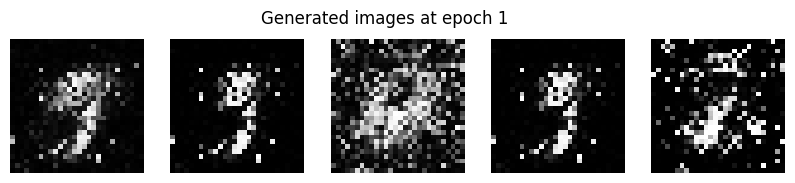

[Epoch 1/50] [Batch 0/938] [D loss: 0.505941] [G loss: 3.205049]
[Epoch 1/50] [Batch 1/938] [D loss: 0.378775] [G loss: 0.893590]
[Epoch 1/50] [Batch 2/938] [D loss: 0.296145] [G loss: 1.302962]
[Epoch 1/50] [Batch 3/938] [D loss: 0.299967] [G loss: 1.895108]
[Epoch 1/50] [Batch 4/938] [D loss: 0.393564] [G loss: 0.906942]
[Epoch 1/50] [Batch 5/938] [D loss: 0.315711] [G loss: 1.637112]
[Epoch 1/50] [Batch 6/938] [D loss: 0.369446] [G loss: 1.189742]
[Epoch 1/50] [Batch 7/938] [D loss: 0.325410] [G loss: 1.102567]
[Epoch 1/50] [Batch 8/938] [D loss: 0.376002] [G loss: 1.852384]
[Epoch 1/50] [Batch 9/938] [D loss: 0.564188] [G loss: 0.479458]
[Epoch 1/50] [Batch 10/938] [D loss: 0.756442] [G loss: 3.567625]
[Epoch 1/50] [Batch 11/938] [D loss: 0.894606] [G loss: 0.222091]
[Epoch 1/50] [Batch 12/938] [D loss: 0.392504] [G loss: 2.752805]
[Epoch 1/50] [Batch 13/938] [D loss: 0.282439] [G loss: 1.490752]
[Epoch 1/50] [Batch 14/938] [D loss: 0.293923] [G loss: 1.128443]
[Epoch 1/50] [Batch 

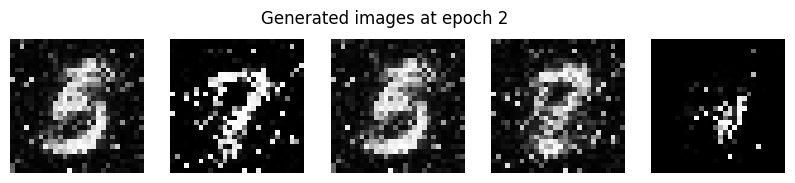

[Epoch 2/50] [Batch 0/938] [D loss: 0.315800] [G loss: 1.387401]
[Epoch 2/50] [Batch 1/938] [D loss: 0.320366] [G loss: 1.703214]
[Epoch 2/50] [Batch 2/938] [D loss: 0.402698] [G loss: 0.974818]
[Epoch 2/50] [Batch 3/938] [D loss: 0.264659] [G loss: 1.825505]
[Epoch 2/50] [Batch 4/938] [D loss: 0.380307] [G loss: 1.368828]
[Epoch 2/50] [Batch 5/938] [D loss: 0.429340] [G loss: 0.793096]
[Epoch 2/50] [Batch 6/938] [D loss: 0.455660] [G loss: 2.511392]
[Epoch 2/50] [Batch 7/938] [D loss: 0.475723] [G loss: 0.639064]
[Epoch 2/50] [Batch 8/938] [D loss: 0.512299] [G loss: 2.393037]
[Epoch 2/50] [Batch 9/938] [D loss: 0.432882] [G loss: 0.668025]
[Epoch 2/50] [Batch 10/938] [D loss: 0.436615] [G loss: 2.351656]
[Epoch 2/50] [Batch 11/938] [D loss: 0.408597] [G loss: 0.834973]
[Epoch 2/50] [Batch 12/938] [D loss: 0.427515] [G loss: 1.615863]
[Epoch 2/50] [Batch 13/938] [D loss: 0.431290] [G loss: 0.859983]
[Epoch 2/50] [Batch 14/938] [D loss: 0.416668] [G loss: 1.905262]
[Epoch 2/50] [Batch 

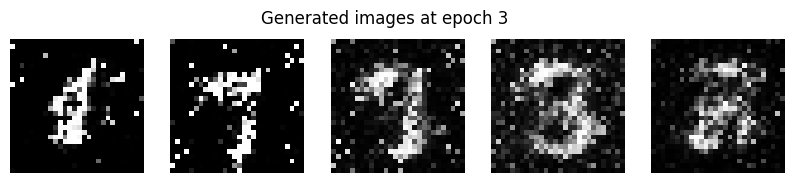

[Epoch 3/50] [Batch 0/938] [D loss: 0.479880] [G loss: 2.524549]
[Epoch 3/50] [Batch 1/938] [D loss: 0.659324] [G loss: 0.412442]
[Epoch 3/50] [Batch 2/938] [D loss: 0.958243] [G loss: 4.608799]
[Epoch 3/50] [Batch 3/938] [D loss: 0.405093] [G loss: 0.784979]
[Epoch 3/50] [Batch 4/938] [D loss: 0.249534] [G loss: 1.493109]
[Epoch 3/50] [Batch 5/938] [D loss: 0.267250] [G loss: 2.416991]
[Epoch 3/50] [Batch 6/938] [D loss: 0.249824] [G loss: 1.433849]
[Epoch 3/50] [Batch 7/938] [D loss: 0.253986] [G loss: 1.575979]
[Epoch 3/50] [Batch 8/938] [D loss: 0.356377] [G loss: 1.769803]
[Epoch 3/50] [Batch 9/938] [D loss: 0.419729] [G loss: 0.701797]
[Epoch 3/50] [Batch 10/938] [D loss: 0.511864] [G loss: 3.470527]
[Epoch 3/50] [Batch 11/938] [D loss: 0.393538] [G loss: 0.932390]
[Epoch 3/50] [Batch 12/938] [D loss: 0.322658] [G loss: 1.359097]
[Epoch 3/50] [Batch 13/938] [D loss: 0.327683] [G loss: 1.753849]
[Epoch 3/50] [Batch 14/938] [D loss: 0.360044] [G loss: 1.110197]
[Epoch 3/50] [Batch 

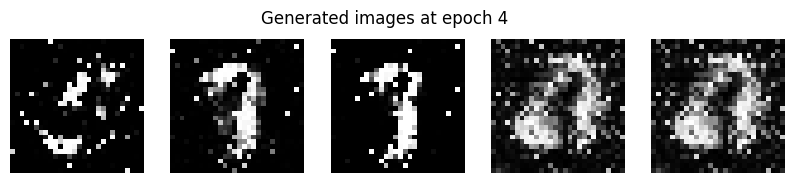

[Epoch 4/50] [Batch 0/938] [D loss: 0.292574] [G loss: 1.169666]
[Epoch 4/50] [Batch 1/938] [D loss: 0.243566] [G loss: 2.459922]
[Epoch 4/50] [Batch 2/938] [D loss: 0.236048] [G loss: 1.393055]
[Epoch 4/50] [Batch 3/938] [D loss: 0.173735] [G loss: 2.218621]
[Epoch 4/50] [Batch 4/938] [D loss: 0.208152] [G loss: 1.797597]
[Epoch 4/50] [Batch 5/938] [D loss: 0.254336] [G loss: 1.448740]
[Epoch 4/50] [Batch 6/938] [D loss: 0.225524] [G loss: 2.030065]
[Epoch 4/50] [Batch 7/938] [D loss: 0.225502] [G loss: 1.458428]
[Epoch 4/50] [Batch 8/938] [D loss: 0.242648] [G loss: 2.229820]
[Epoch 4/50] [Batch 9/938] [D loss: 0.203389] [G loss: 1.408999]
[Epoch 4/50] [Batch 10/938] [D loss: 0.214623] [G loss: 2.705833]
[Epoch 4/50] [Batch 11/938] [D loss: 0.178861] [G loss: 1.501594]
[Epoch 4/50] [Batch 12/938] [D loss: 0.208737] [G loss: 2.246496]
[Epoch 4/50] [Batch 13/938] [D loss: 0.167860] [G loss: 1.515515]
[Epoch 4/50] [Batch 14/938] [D loss: 0.215093] [G loss: 2.417073]
[Epoch 4/50] [Batch 

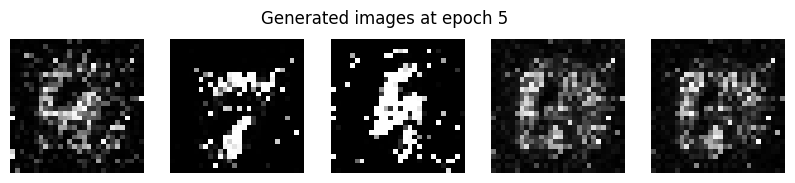

[Epoch 5/50] [Batch 0/938] [D loss: 0.228761] [G loss: 1.558146]
[Epoch 5/50] [Batch 1/938] [D loss: 0.243927] [G loss: 2.752753]
[Epoch 5/50] [Batch 2/938] [D loss: 0.418105] [G loss: 0.632828]
[Epoch 5/50] [Batch 3/938] [D loss: 1.416239] [G loss: 7.525882]
[Epoch 5/50] [Batch 4/938] [D loss: 0.770026] [G loss: 0.292080]
[Epoch 5/50] [Batch 5/938] [D loss: 0.720263] [G loss: 7.247540]
[Epoch 5/50] [Batch 6/938] [D loss: 0.083442] [G loss: 3.186831]
[Epoch 5/50] [Batch 7/938] [D loss: 0.403405] [G loss: 0.674930]
[Epoch 5/50] [Batch 8/938] [D loss: 0.275450] [G loss: 5.578305]
[Epoch 5/50] [Batch 9/938] [D loss: 0.084520] [G loss: 3.994387]
[Epoch 5/50] [Batch 10/938] [D loss: 0.163241] [G loss: 1.560796]
[Epoch 5/50] [Batch 11/938] [D loss: 0.090229] [G loss: 2.322495]
[Epoch 5/50] [Batch 12/938] [D loss: 0.207799] [G loss: 2.799725]
[Epoch 5/50] [Batch 13/938] [D loss: 0.312436] [G loss: 1.122642]
[Epoch 5/50] [Batch 14/938] [D loss: 0.423476] [G loss: 3.197957]
[Epoch 5/50] [Batch 

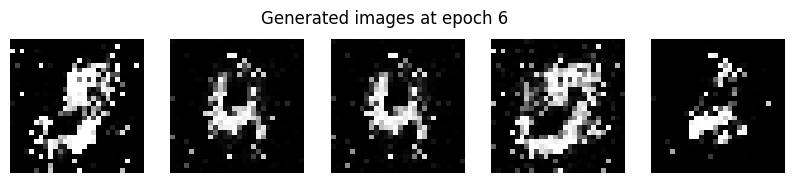

[Epoch 6/50] [Batch 0/938] [D loss: 0.314477] [G loss: 1.042351]
[Epoch 6/50] [Batch 1/938] [D loss: 0.521518] [G loss: 4.297069]
[Epoch 6/50] [Batch 2/938] [D loss: 0.536969] [G loss: 1.170227]
[Epoch 6/50] [Batch 3/938] [D loss: 0.516555] [G loss: 4.440571]
[Epoch 6/50] [Batch 4/938] [D loss: 0.446886] [G loss: 1.657262]
[Epoch 6/50] [Batch 5/938] [D loss: 0.282088] [G loss: 1.561184]
[Epoch 6/50] [Batch 6/938] [D loss: 0.431886] [G loss: 3.200051]
[Epoch 6/50] [Batch 7/938] [D loss: 0.360409] [G loss: 0.879483]
[Epoch 6/50] [Batch 8/938] [D loss: 0.267398] [G loss: 3.302332]
[Epoch 6/50] [Batch 9/938] [D loss: 0.257564] [G loss: 1.443737]
[Epoch 6/50] [Batch 10/938] [D loss: 0.310608] [G loss: 1.429617]
[Epoch 6/50] [Batch 11/938] [D loss: 0.257672] [G loss: 2.139747]
[Epoch 6/50] [Batch 12/938] [D loss: 0.223519] [G loss: 1.363773]
[Epoch 6/50] [Batch 13/938] [D loss: 0.301354] [G loss: 2.697654]
[Epoch 6/50] [Batch 14/938] [D loss: 0.336879] [G loss: 1.311607]
[Epoch 6/50] [Batch 

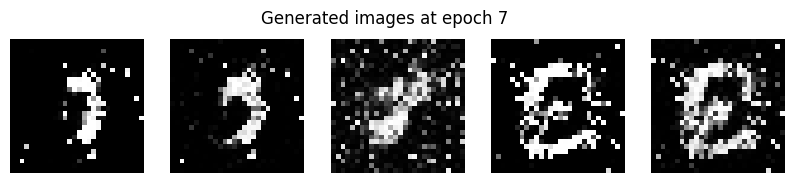

[Epoch 7/50] [Batch 0/938] [D loss: 0.595956] [G loss: 5.069355]
[Epoch 7/50] [Batch 1/938] [D loss: 0.185061] [G loss: 1.588040]
[Epoch 7/50] [Batch 2/938] [D loss: 0.156940] [G loss: 1.618292]
[Epoch 7/50] [Batch 3/938] [D loss: 0.175053] [G loss: 3.307821]
[Epoch 7/50] [Batch 4/938] [D loss: 0.143941] [G loss: 2.207561]
[Epoch 7/50] [Batch 5/938] [D loss: 0.158186] [G loss: 1.998278]
[Epoch 7/50] [Batch 6/938] [D loss: 0.188181] [G loss: 2.201051]
[Epoch 7/50] [Batch 7/938] [D loss: 0.292587] [G loss: 2.008255]
[Epoch 7/50] [Batch 8/938] [D loss: 0.253007] [G loss: 1.323006]
[Epoch 7/50] [Batch 9/938] [D loss: 0.201943] [G loss: 3.322819]
[Epoch 7/50] [Batch 10/938] [D loss: 0.234260] [G loss: 2.290000]
[Epoch 7/50] [Batch 11/938] [D loss: 0.273036] [G loss: 1.247550]
[Epoch 7/50] [Batch 12/938] [D loss: 0.336093] [G loss: 3.047881]
[Epoch 7/50] [Batch 13/938] [D loss: 0.269223] [G loss: 1.362256]
[Epoch 7/50] [Batch 14/938] [D loss: 0.224741] [G loss: 2.588634]
[Epoch 7/50] [Batch 

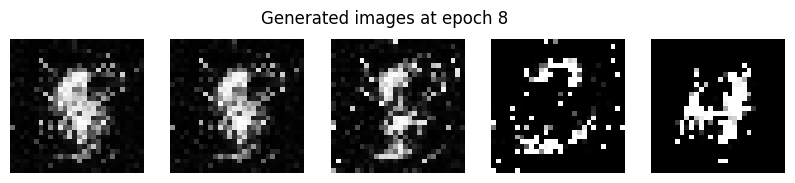

[Epoch 8/50] [Batch 0/938] [D loss: 0.335198] [G loss: 2.639091]
[Epoch 8/50] [Batch 1/938] [D loss: 0.442203] [G loss: 0.755242]
[Epoch 8/50] [Batch 2/938] [D loss: 1.058287] [G loss: 6.666907]
[Epoch 8/50] [Batch 3/938] [D loss: 1.067333] [G loss: 0.225430]
[Epoch 8/50] [Batch 4/938] [D loss: 1.178458] [G loss: 9.214176]
[Epoch 8/50] [Batch 5/938] [D loss: 0.066500] [G loss: 4.168520]
[Epoch 8/50] [Batch 6/938] [D loss: 0.384612] [G loss: 1.174743]
[Epoch 8/50] [Batch 7/938] [D loss: 0.114768] [G loss: 4.731401]
[Epoch 8/50] [Batch 8/938] [D loss: 0.214548] [G loss: 5.004252]
[Epoch 8/50] [Batch 9/938] [D loss: 0.172286] [G loss: 3.201994]
[Epoch 8/50] [Batch 10/938] [D loss: 0.108512] [G loss: 3.302234]
[Epoch 8/50] [Batch 11/938] [D loss: 0.083518] [G loss: 2.789241]
[Epoch 8/50] [Batch 12/938] [D loss: 0.074709] [G loss: 2.715287]
[Epoch 8/50] [Batch 13/938] [D loss: 0.134262] [G loss: 3.279209]
[Epoch 8/50] [Batch 14/938] [D loss: 0.115774] [G loss: 2.154400]
[Epoch 8/50] [Batch 

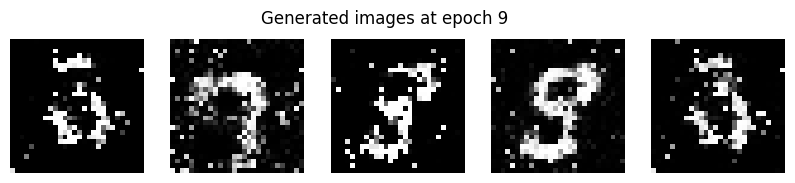

[Epoch 9/50] [Batch 0/938] [D loss: 0.144135] [G loss: 2.700657]
[Epoch 9/50] [Batch 1/938] [D loss: 0.188634] [G loss: 1.714435]
[Epoch 9/50] [Batch 2/938] [D loss: 0.219758] [G loss: 2.607175]
[Epoch 9/50] [Batch 3/938] [D loss: 0.211799] [G loss: 1.518356]
[Epoch 9/50] [Batch 4/938] [D loss: 0.224328] [G loss: 3.010946]
[Epoch 9/50] [Batch 5/938] [D loss: 0.326762] [G loss: 1.433426]
[Epoch 9/50] [Batch 6/938] [D loss: 0.264559] [G loss: 1.322254]
[Epoch 9/50] [Batch 7/938] [D loss: 0.308530] [G loss: 4.312417]
[Epoch 9/50] [Batch 8/938] [D loss: 0.211228] [G loss: 1.763541]
[Epoch 9/50] [Batch 9/938] [D loss: 0.207582] [G loss: 1.316006]
[Epoch 9/50] [Batch 10/938] [D loss: 0.359259] [G loss: 4.238908]
[Epoch 9/50] [Batch 11/938] [D loss: 0.194155] [G loss: 1.947363]
[Epoch 9/50] [Batch 12/938] [D loss: 0.233623] [G loss: 1.638383]
[Epoch 9/50] [Batch 13/938] [D loss: 0.241647] [G loss: 2.973016]
[Epoch 9/50] [Batch 14/938] [D loss: 0.159015] [G loss: 1.997461]
[Epoch 9/50] [Batch 

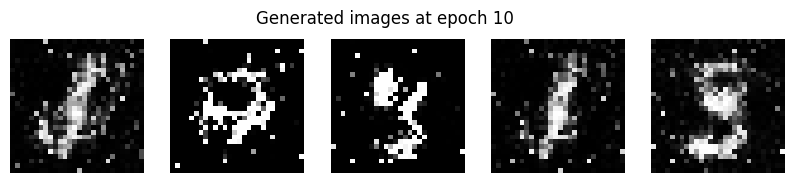

[Epoch 10/50] [Batch 0/938] [D loss: 0.150585] [G loss: 3.715390]
[Epoch 10/50] [Batch 1/938] [D loss: 0.118611] [G loss: 2.643152]
[Epoch 10/50] [Batch 2/938] [D loss: 0.216984] [G loss: 1.779978]
[Epoch 10/50] [Batch 3/938] [D loss: 0.276359] [G loss: 2.753520]
[Epoch 10/50] [Batch 4/938] [D loss: 0.342307] [G loss: 1.033229]
[Epoch 10/50] [Batch 5/938] [D loss: 0.653786] [G loss: 4.138267]
[Epoch 10/50] [Batch 6/938] [D loss: 0.720369] [G loss: 0.363771]
[Epoch 10/50] [Batch 7/938] [D loss: 1.457545] [G loss: 7.832733]
[Epoch 10/50] [Batch 8/938] [D loss: 0.259976] [G loss: 1.493054]
[Epoch 10/50] [Batch 9/938] [D loss: 0.175713] [G loss: 1.970689]
[Epoch 10/50] [Batch 10/938] [D loss: 0.138558] [G loss: 3.142658]
[Epoch 10/50] [Batch 11/938] [D loss: 0.096776] [G loss: 2.313908]
[Epoch 10/50] [Batch 12/938] [D loss: 0.186881] [G loss: 1.847453]
[Epoch 10/50] [Batch 13/938] [D loss: 0.232486] [G loss: 2.062816]
[Epoch 10/50] [Batch 14/938] [D loss: 0.302203] [G loss: 1.176915]
[Epoc

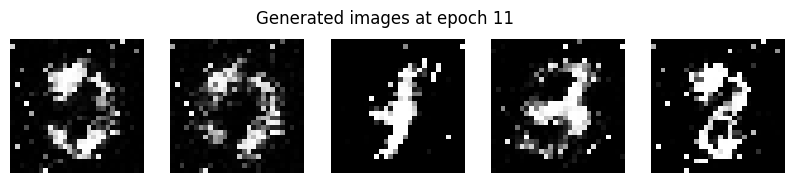

[Epoch 11/50] [Batch 0/938] [D loss: 0.604040] [G loss: 0.505438]
[Epoch 11/50] [Batch 1/938] [D loss: 0.748028] [G loss: 4.742011]
[Epoch 11/50] [Batch 2/938] [D loss: 0.358114] [G loss: 1.455402]
[Epoch 11/50] [Batch 3/938] [D loss: 0.286950] [G loss: 1.329806]
[Epoch 11/50] [Batch 4/938] [D loss: 0.226699] [G loss: 2.765455]
[Epoch 11/50] [Batch 5/938] [D loss: 0.295576] [G loss: 1.733180]
[Epoch 11/50] [Batch 6/938] [D loss: 0.291930] [G loss: 1.101700]
[Epoch 11/50] [Batch 7/938] [D loss: 0.320050] [G loss: 3.358709]
[Epoch 11/50] [Batch 8/938] [D loss: 0.265303] [G loss: 1.578353]
[Epoch 11/50] [Batch 9/938] [D loss: 0.244467] [G loss: 1.414459]
[Epoch 11/50] [Batch 10/938] [D loss: 0.249129] [G loss: 2.678335]
[Epoch 11/50] [Batch 11/938] [D loss: 0.240258] [G loss: 1.428423]
[Epoch 11/50] [Batch 12/938] [D loss: 0.228892] [G loss: 1.968067]
[Epoch 11/50] [Batch 13/938] [D loss: 0.260262] [G loss: 1.936226]
[Epoch 11/50] [Batch 14/938] [D loss: 0.253902] [G loss: 1.488269]
[Epoc

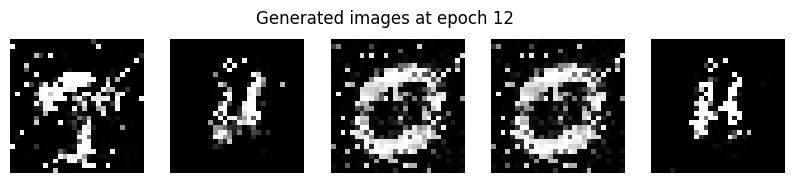

[Epoch 12/50] [Batch 0/938] [D loss: 0.201256] [G loss: 2.532283]
[Epoch 12/50] [Batch 1/938] [D loss: 0.150215] [G loss: 2.140632]
[Epoch 12/50] [Batch 2/938] [D loss: 0.235582] [G loss: 2.201965]
[Epoch 12/50] [Batch 3/938] [D loss: 0.216570] [G loss: 1.555109]
[Epoch 12/50] [Batch 4/938] [D loss: 0.252085] [G loss: 2.725665]
[Epoch 12/50] [Batch 5/938] [D loss: 0.256493] [G loss: 1.526943]
[Epoch 12/50] [Batch 6/938] [D loss: 0.171531] [G loss: 2.428681]
[Epoch 12/50] [Batch 7/938] [D loss: 0.270487] [G loss: 2.537204]
[Epoch 12/50] [Batch 8/938] [D loss: 0.267464] [G loss: 1.698379]
[Epoch 12/50] [Batch 9/938] [D loss: 0.331278] [G loss: 3.144947]
[Epoch 12/50] [Batch 10/938] [D loss: 0.252320] [G loss: 1.344117]
[Epoch 12/50] [Batch 11/938] [D loss: 0.171630] [G loss: 2.832470]
[Epoch 12/50] [Batch 12/938] [D loss: 0.181864] [G loss: 2.534162]
[Epoch 12/50] [Batch 13/938] [D loss: 0.177137] [G loss: 1.812673]
[Epoch 12/50] [Batch 14/938] [D loss: 0.138848] [G loss: 2.412800]
[Epoc

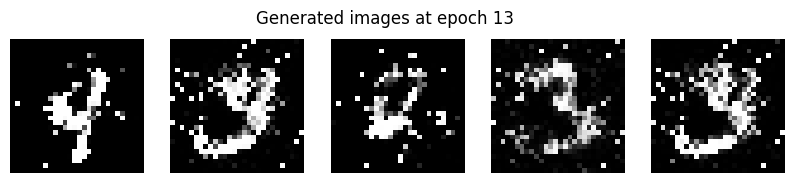

[Epoch 13/50] [Batch 0/938] [D loss: 0.105885] [G loss: 2.251192]
[Epoch 13/50] [Batch 1/938] [D loss: 0.122419] [G loss: 2.264739]
[Epoch 13/50] [Batch 2/938] [D loss: 0.116756] [G loss: 2.672957]
[Epoch 13/50] [Batch 3/938] [D loss: 0.096232] [G loss: 2.210504]
[Epoch 13/50] [Batch 4/938] [D loss: 0.127987] [G loss: 2.969086]
[Epoch 13/50] [Batch 5/938] [D loss: 0.187048] [G loss: 2.383563]
[Epoch 13/50] [Batch 6/938] [D loss: 0.233119] [G loss: 1.525649]
[Epoch 13/50] [Batch 7/938] [D loss: 0.153590] [G loss: 2.903994]
[Epoch 13/50] [Batch 8/938] [D loss: 0.220438] [G loss: 2.330589]
[Epoch 13/50] [Batch 9/938] [D loss: 0.215967] [G loss: 1.744733]
[Epoch 13/50] [Batch 10/938] [D loss: 0.119348] [G loss: 2.684175]
[Epoch 13/50] [Batch 11/938] [D loss: 0.174689] [G loss: 2.352133]
[Epoch 13/50] [Batch 12/938] [D loss: 0.162220] [G loss: 1.714737]
[Epoch 13/50] [Batch 13/938] [D loss: 0.278704] [G loss: 3.228983]
[Epoch 13/50] [Batch 14/938] [D loss: 0.295852] [G loss: 1.412215]
[Epoc

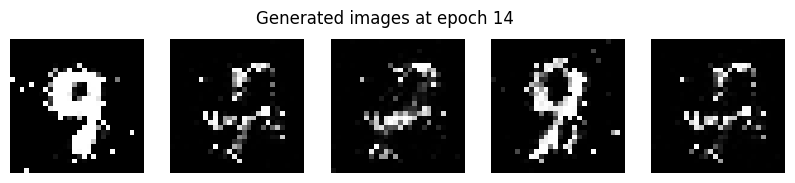

[Epoch 14/50] [Batch 0/938] [D loss: 0.182173] [G loss: 2.930955]
[Epoch 14/50] [Batch 1/938] [D loss: 0.196899] [G loss: 1.619602]
[Epoch 14/50] [Batch 2/938] [D loss: 0.352483] [G loss: 3.164771]
[Epoch 14/50] [Batch 3/938] [D loss: 0.350436] [G loss: 0.964721]
[Epoch 14/50] [Batch 4/938] [D loss: 0.686195] [G loss: 5.368175]
[Epoch 14/50] [Batch 5/938] [D loss: 0.348720] [G loss: 0.871950]
[Epoch 14/50] [Batch 6/938] [D loss: 0.446426] [G loss: 5.357938]
[Epoch 14/50] [Batch 7/938] [D loss: 0.151854] [G loss: 2.824617]
[Epoch 14/50] [Batch 8/938] [D loss: 0.322574] [G loss: 0.991544]
[Epoch 14/50] [Batch 9/938] [D loss: 0.283865] [G loss: 5.550880]
[Epoch 14/50] [Batch 10/938] [D loss: 0.102517] [G loss: 4.082533]
[Epoch 14/50] [Batch 11/938] [D loss: 0.155799] [G loss: 1.753988]
[Epoch 14/50] [Batch 12/938] [D loss: 0.111215] [G loss: 2.540179]
[Epoch 14/50] [Batch 13/938] [D loss: 0.171168] [G loss: 2.808519]
[Epoch 14/50] [Batch 14/938] [D loss: 0.132882] [G loss: 1.946829]
[Epoc

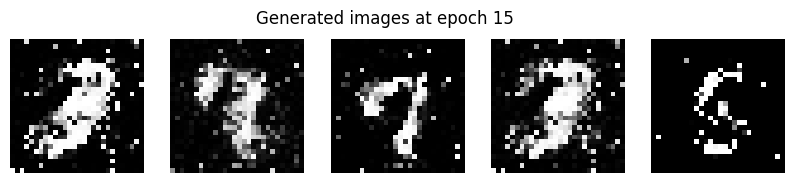

[Epoch 15/50] [Batch 0/938] [D loss: 0.516901] [G loss: 0.521649]
[Epoch 15/50] [Batch 1/938] [D loss: 0.737892] [G loss: 6.534080]
[Epoch 15/50] [Batch 2/938] [D loss: 0.165855] [G loss: 3.582510]
[Epoch 15/50] [Batch 3/938] [D loss: 0.300593] [G loss: 0.926893]
[Epoch 15/50] [Batch 4/938] [D loss: 0.103393] [G loss: 4.005375]
[Epoch 15/50] [Batch 5/938] [D loss: 0.159792] [G loss: 4.116405]
[Epoch 15/50] [Batch 6/938] [D loss: 0.141508] [G loss: 2.180089]
[Epoch 15/50] [Batch 7/938] [D loss: 0.127994] [G loss: 1.766515]
[Epoch 15/50] [Batch 8/938] [D loss: 0.168389] [G loss: 3.121247]
[Epoch 15/50] [Batch 9/938] [D loss: 0.157421] [G loss: 2.583417]
[Epoch 15/50] [Batch 10/938] [D loss: 0.125554] [G loss: 1.871827]
[Epoch 15/50] [Batch 11/938] [D loss: 0.193456] [G loss: 3.194532]
[Epoch 15/50] [Batch 12/938] [D loss: 0.192026] [G loss: 1.791181]
[Epoch 15/50] [Batch 13/938] [D loss: 0.291233] [G loss: 2.241353]
[Epoch 15/50] [Batch 14/938] [D loss: 0.230699] [G loss: 1.737520]
[Epoc

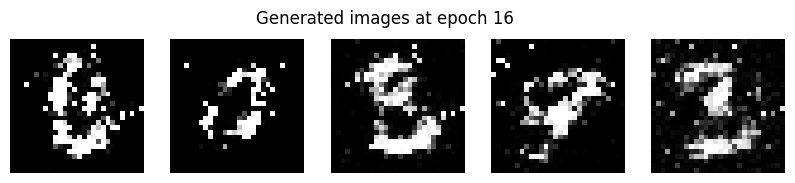

[Epoch 16/50] [Batch 0/938] [D loss: 0.425702] [G loss: 0.722142]
[Epoch 16/50] [Batch 1/938] [D loss: 0.514688] [G loss: 5.304182]
[Epoch 16/50] [Batch 2/938] [D loss: 0.209049] [G loss: 2.603212]
[Epoch 16/50] [Batch 3/938] [D loss: 0.370521] [G loss: 0.779479]
[Epoch 16/50] [Batch 4/938] [D loss: 0.473888] [G loss: 5.355203]
[Epoch 16/50] [Batch 5/938] [D loss: 0.242088] [G loss: 3.007582]
[Epoch 16/50] [Batch 6/938] [D loss: 0.394634] [G loss: 0.793020]
[Epoch 16/50] [Batch 7/938] [D loss: 0.343185] [G loss: 4.629459]
[Epoch 16/50] [Batch 8/938] [D loss: 0.233108] [G loss: 3.014449]
[Epoch 16/50] [Batch 9/938] [D loss: 0.352048] [G loss: 1.004739]
[Epoch 16/50] [Batch 10/938] [D loss: 0.353474] [G loss: 3.745005]
[Epoch 16/50] [Batch 11/938] [D loss: 0.258661] [G loss: 2.041875]
[Epoch 16/50] [Batch 12/938] [D loss: 0.274117] [G loss: 1.055859]
[Epoch 16/50] [Batch 13/938] [D loss: 0.297374] [G loss: 4.409645]
[Epoch 16/50] [Batch 14/938] [D loss: 0.280375] [G loss: 2.428210]
[Epoc

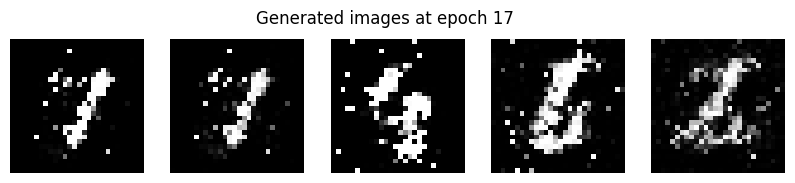

[Epoch 17/50] [Batch 0/938] [D loss: 0.333727] [G loss: 0.991332]
[Epoch 17/50] [Batch 1/938] [D loss: 0.565844] [G loss: 5.759717]
[Epoch 17/50] [Batch 2/938] [D loss: 0.153419] [G loss: 1.701249]
[Epoch 17/50] [Batch 3/938] [D loss: 0.164168] [G loss: 1.920433]
[Epoch 17/50] [Batch 4/938] [D loss: 0.224696] [G loss: 3.383175]
[Epoch 17/50] [Batch 5/938] [D loss: 0.188955] [G loss: 1.739193]
[Epoch 17/50] [Batch 6/938] [D loss: 0.198816] [G loss: 2.739878]
[Epoch 17/50] [Batch 7/938] [D loss: 0.194836] [G loss: 1.988824]
[Epoch 17/50] [Batch 8/938] [D loss: 0.215416] [G loss: 1.988171]
[Epoch 17/50] [Batch 9/938] [D loss: 0.249595] [G loss: 2.637421]
[Epoch 17/50] [Batch 10/938] [D loss: 0.227429] [G loss: 1.559675]
[Epoch 17/50] [Batch 11/938] [D loss: 0.350337] [G loss: 3.573455]
[Epoch 17/50] [Batch 12/938] [D loss: 0.267634] [G loss: 1.274932]
[Epoch 17/50] [Batch 13/938] [D loss: 0.395703] [G loss: 3.337579]
[Epoch 17/50] [Batch 14/938] [D loss: 0.795186] [G loss: 0.330345]
[Epoc

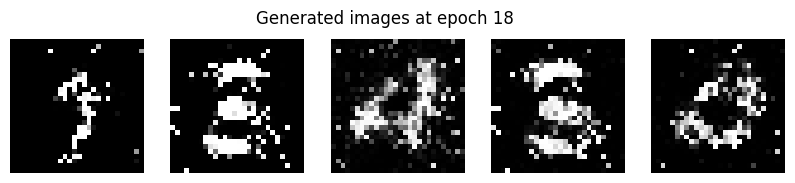

[Epoch 18/50] [Batch 0/938] [D loss: 0.217389] [G loss: 1.695510]
[Epoch 18/50] [Batch 1/938] [D loss: 0.179100] [G loss: 2.356906]
[Epoch 18/50] [Batch 2/938] [D loss: 0.191806] [G loss: 3.152078]
[Epoch 18/50] [Batch 3/938] [D loss: 0.218463] [G loss: 1.944693]
[Epoch 18/50] [Batch 4/938] [D loss: 0.143071] [G loss: 4.064619]
[Epoch 18/50] [Batch 5/938] [D loss: 0.164359] [G loss: 2.758240]
[Epoch 18/50] [Batch 6/938] [D loss: 0.247596] [G loss: 2.186762]
[Epoch 18/50] [Batch 7/938] [D loss: 0.147138] [G loss: 1.810667]
[Epoch 18/50] [Batch 8/938] [D loss: 0.231188] [G loss: 5.042206]
[Epoch 18/50] [Batch 9/938] [D loss: 0.154807] [G loss: 2.623237]
[Epoch 18/50] [Batch 10/938] [D loss: 0.221901] [G loss: 1.702439]
[Epoch 18/50] [Batch 11/938] [D loss: 0.374985] [G loss: 4.440018]
[Epoch 18/50] [Batch 12/938] [D loss: 0.284119] [G loss: 1.236557]
[Epoch 18/50] [Batch 13/938] [D loss: 0.373545] [G loss: 4.656574]
[Epoch 18/50] [Batch 14/938] [D loss: 0.151786] [G loss: 1.716482]
[Epoc

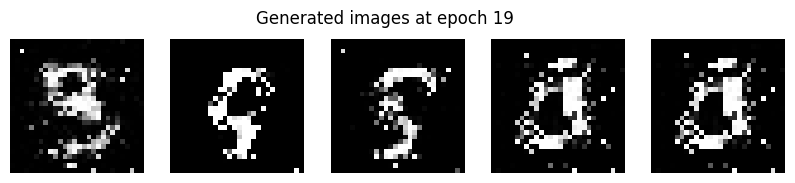

[Epoch 19/50] [Batch 0/938] [D loss: 0.182944] [G loss: 3.026004]
[Epoch 19/50] [Batch 1/938] [D loss: 0.272634] [G loss: 1.838742]
[Epoch 19/50] [Batch 2/938] [D loss: 0.226882] [G loss: 2.449349]
[Epoch 19/50] [Batch 3/938] [D loss: 0.158821] [G loss: 1.933910]
[Epoch 19/50] [Batch 4/938] [D loss: 0.223570] [G loss: 3.868648]
[Epoch 19/50] [Batch 5/938] [D loss: 0.173742] [G loss: 2.307759]
[Epoch 19/50] [Batch 6/938] [D loss: 0.136648] [G loss: 1.817067]
[Epoch 19/50] [Batch 7/938] [D loss: 0.219455] [G loss: 3.612924]
[Epoch 19/50] [Batch 8/938] [D loss: 0.182071] [G loss: 2.125012]
[Epoch 19/50] [Batch 9/938] [D loss: 0.187822] [G loss: 1.773701]
[Epoch 19/50] [Batch 10/938] [D loss: 0.311183] [G loss: 3.103695]
[Epoch 19/50] [Batch 11/938] [D loss: 0.223813] [G loss: 1.356510]
[Epoch 19/50] [Batch 12/938] [D loss: 0.164555] [G loss: 4.523645]
[Epoch 19/50] [Batch 13/938] [D loss: 0.178767] [G loss: 3.603743]
[Epoch 19/50] [Batch 14/938] [D loss: 0.327060] [G loss: 1.095288]
[Epoc

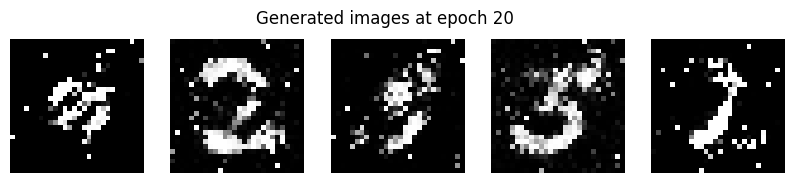

[Epoch 20/50] [Batch 0/938] [D loss: 0.185311] [G loss: 3.580158]
[Epoch 20/50] [Batch 1/938] [D loss: 0.385263] [G loss: 0.820574]
[Epoch 20/50] [Batch 2/938] [D loss: 0.476629] [G loss: 7.333405]
[Epoch 20/50] [Batch 3/938] [D loss: 0.072515] [G loss: 4.584521]
[Epoch 20/50] [Batch 4/938] [D loss: 0.243683] [G loss: 1.682147]
[Epoch 20/50] [Batch 5/938] [D loss: 0.156762] [G loss: 4.430258]
[Epoch 20/50] [Batch 6/938] [D loss: 0.122334] [G loss: 4.081677]
[Epoch 20/50] [Batch 7/938] [D loss: 0.181144] [G loss: 2.438405]
[Epoch 20/50] [Batch 8/938] [D loss: 0.202507] [G loss: 3.672119]
[Epoch 20/50] [Batch 9/938] [D loss: 0.125093] [G loss: 1.983397]
[Epoch 20/50] [Batch 10/938] [D loss: 0.060790] [G loss: 2.961540]
[Epoch 20/50] [Batch 11/938] [D loss: 0.108132] [G loss: 3.521703]
[Epoch 20/50] [Batch 12/938] [D loss: 0.129082] [G loss: 2.087276]
[Epoch 20/50] [Batch 13/938] [D loss: 0.171105] [G loss: 2.466412]
[Epoch 20/50] [Batch 14/938] [D loss: 0.153003] [G loss: 2.469109]
[Epoc

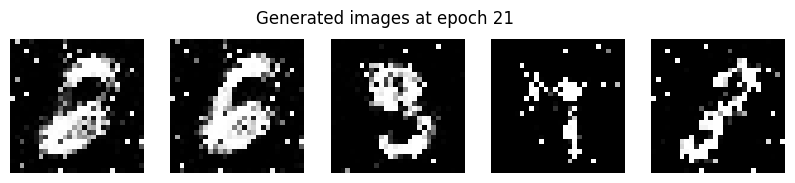

[Epoch 21/50] [Batch 0/938] [D loss: 0.193846] [G loss: 1.507877]
[Epoch 21/50] [Batch 1/938] [D loss: 0.186119] [G loss: 4.724342]
[Epoch 21/50] [Batch 2/938] [D loss: 0.140687] [G loss: 3.380098]
[Epoch 21/50] [Batch 3/938] [D loss: 0.245153] [G loss: 1.363786]
[Epoch 21/50] [Batch 4/938] [D loss: 0.187256] [G loss: 4.555130]
[Epoch 21/50] [Batch 5/938] [D loss: 0.135356] [G loss: 3.701056]
[Epoch 21/50] [Batch 6/938] [D loss: 0.161909] [G loss: 2.276633]
[Epoch 21/50] [Batch 7/938] [D loss: 0.234682] [G loss: 3.508344]
[Epoch 21/50] [Batch 8/938] [D loss: 0.173511] [G loss: 1.841162]
[Epoch 21/50] [Batch 9/938] [D loss: 0.170497] [G loss: 2.785914]
[Epoch 21/50] [Batch 10/938] [D loss: 0.171709] [G loss: 2.541812]
[Epoch 21/50] [Batch 11/938] [D loss: 0.181232] [G loss: 1.874107]
[Epoch 21/50] [Batch 12/938] [D loss: 0.128107] [G loss: 3.417033]
[Epoch 21/50] [Batch 13/938] [D loss: 0.153730] [G loss: 2.778005]
[Epoch 21/50] [Batch 14/938] [D loss: 0.194709] [G loss: 1.583877]
[Epoc

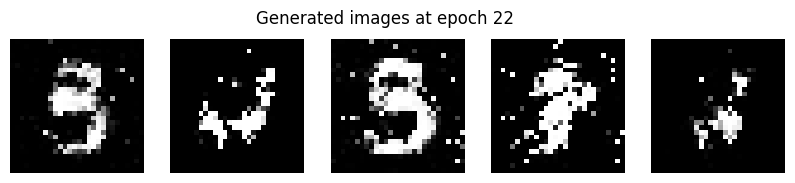

[Epoch 22/50] [Batch 0/938] [D loss: 0.105561] [G loss: 2.876585]
[Epoch 22/50] [Batch 1/938] [D loss: 0.248583] [G loss: 2.891551]
[Epoch 22/50] [Batch 2/938] [D loss: 0.189800] [G loss: 1.451619]
[Epoch 22/50] [Batch 3/938] [D loss: 0.204585] [G loss: 3.532228]
[Epoch 22/50] [Batch 4/938] [D loss: 0.192229] [G loss: 2.494853]
[Epoch 22/50] [Batch 5/938] [D loss: 0.289581] [G loss: 1.033021]
[Epoch 22/50] [Batch 6/938] [D loss: 0.330927] [G loss: 5.424003]
[Epoch 22/50] [Batch 7/938] [D loss: 0.196907] [G loss: 3.467491]
[Epoch 22/50] [Batch 8/938] [D loss: 0.385731] [G loss: 1.034796]
[Epoch 22/50] [Batch 9/938] [D loss: 0.257072] [G loss: 5.330291]
[Epoch 22/50] [Batch 10/938] [D loss: 0.329141] [G loss: 4.558393]
[Epoch 22/50] [Batch 11/938] [D loss: 0.475740] [G loss: 1.215756]
[Epoch 22/50] [Batch 12/938] [D loss: 0.293774] [G loss: 5.298162]
[Epoch 22/50] [Batch 13/938] [D loss: 0.125744] [G loss: 4.199004]
[Epoch 22/50] [Batch 14/938] [D loss: 0.262683] [G loss: 2.286576]
[Epoc

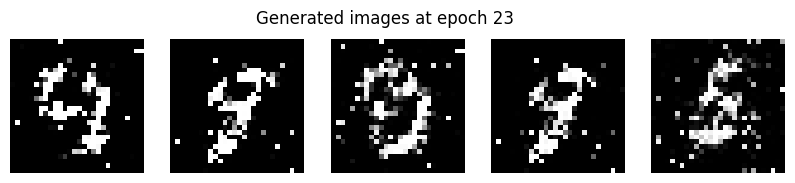

[Epoch 23/50] [Batch 0/938] [D loss: 0.328552] [G loss: 1.045877]
[Epoch 23/50] [Batch 1/938] [D loss: 0.580775] [G loss: 7.045121]
[Epoch 23/50] [Batch 2/938] [D loss: 0.073784] [G loss: 2.917617]
[Epoch 23/50] [Batch 3/938] [D loss: 0.183004] [G loss: 1.673205]
[Epoch 23/50] [Batch 4/938] [D loss: 0.244767] [G loss: 4.954106]
[Epoch 23/50] [Batch 5/938] [D loss: 0.104651] [G loss: 3.140575]
[Epoch 23/50] [Batch 6/938] [D loss: 0.171348] [G loss: 1.544434]
[Epoch 23/50] [Batch 7/938] [D loss: 0.138723] [G loss: 4.412571]
[Epoch 23/50] [Batch 8/938] [D loss: 0.089694] [G loss: 3.326730]
[Epoch 23/50] [Batch 9/938] [D loss: 0.125658] [G loss: 1.944847]
[Epoch 23/50] [Batch 10/938] [D loss: 0.093793] [G loss: 2.762138]
[Epoch 23/50] [Batch 11/938] [D loss: 0.153194] [G loss: 2.742547]
[Epoch 23/50] [Batch 12/938] [D loss: 0.172233] [G loss: 1.655506]
[Epoch 23/50] [Batch 13/938] [D loss: 0.227222] [G loss: 3.636195]
[Epoch 23/50] [Batch 14/938] [D loss: 0.204702] [G loss: 2.016215]
[Epoc

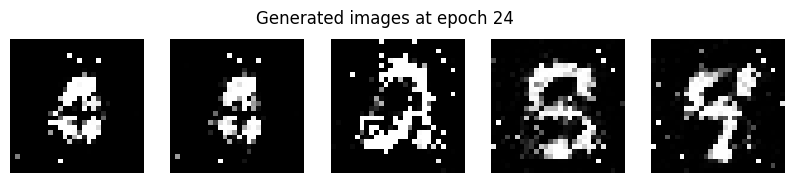

[Epoch 24/50] [Batch 0/938] [D loss: 0.197051] [G loss: 1.577433]
[Epoch 24/50] [Batch 1/938] [D loss: 0.189653] [G loss: 4.094612]
[Epoch 24/50] [Batch 2/938] [D loss: 0.079582] [G loss: 2.951529]
[Epoch 24/50] [Batch 3/938] [D loss: 0.183004] [G loss: 1.979639]
[Epoch 24/50] [Batch 4/938] [D loss: 0.165786] [G loss: 3.095379]
[Epoch 24/50] [Batch 5/938] [D loss: 0.125080] [G loss: 2.069959]
[Epoch 24/50] [Batch 6/938] [D loss: 0.154030] [G loss: 2.792759]
[Epoch 24/50] [Batch 7/938] [D loss: 0.104456] [G loss: 2.242439]
[Epoch 24/50] [Batch 8/938] [D loss: 0.198586] [G loss: 3.081176]
[Epoch 24/50] [Batch 9/938] [D loss: 0.183166] [G loss: 1.501886]
[Epoch 24/50] [Batch 10/938] [D loss: 0.147177] [G loss: 4.399746]
[Epoch 24/50] [Batch 11/938] [D loss: 0.072431] [G loss: 3.269576]
[Epoch 24/50] [Batch 12/938] [D loss: 0.185230] [G loss: 2.163559]
[Epoch 24/50] [Batch 13/938] [D loss: 0.111911] [G loss: 2.408846]
[Epoch 24/50] [Batch 14/938] [D loss: 0.188344] [G loss: 3.368728]
[Epoc

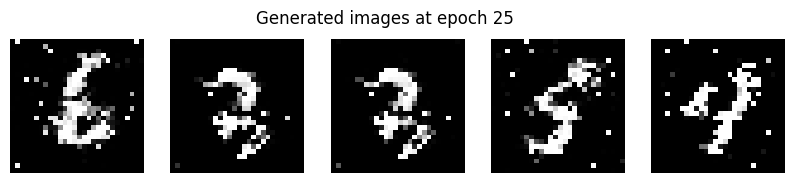

[Epoch 25/50] [Batch 0/938] [D loss: 0.185204] [G loss: 3.125814]
[Epoch 25/50] [Batch 1/938] [D loss: 0.217874] [G loss: 1.328093]
[Epoch 25/50] [Batch 2/938] [D loss: 0.180836] [G loss: 4.225748]
[Epoch 25/50] [Batch 3/938] [D loss: 0.209291] [G loss: 3.021027]
[Epoch 25/50] [Batch 4/938] [D loss: 0.125145] [G loss: 2.039185]
[Epoch 25/50] [Batch 5/938] [D loss: 0.235987] [G loss: 3.552205]
[Epoch 25/50] [Batch 6/938] [D loss: 0.217671] [G loss: 1.545324]
[Epoch 25/50] [Batch 7/938] [D loss: 0.356392] [G loss: 4.347193]
[Epoch 25/50] [Batch 8/938] [D loss: 0.255894] [G loss: 1.300294]
[Epoch 25/50] [Batch 9/938] [D loss: 0.287891] [G loss: 4.653552]
[Epoch 25/50] [Batch 10/938] [D loss: 0.105191] [G loss: 1.984358]
[Epoch 25/50] [Batch 11/938] [D loss: 0.107300] [G loss: 3.076108]
[Epoch 25/50] [Batch 12/938] [D loss: 0.132755] [G loss: 2.564623]
[Epoch 25/50] [Batch 13/938] [D loss: 0.125014] [G loss: 2.355386]
[Epoch 25/50] [Batch 14/938] [D loss: 0.186318] [G loss: 2.764554]
[Epoc

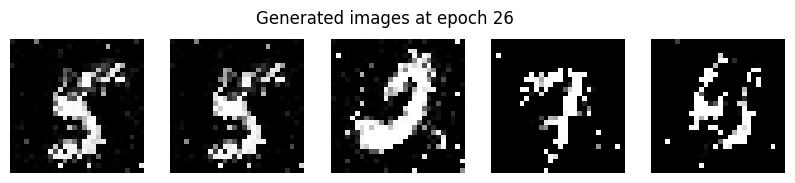

[Epoch 26/50] [Batch 0/938] [D loss: 0.204024] [G loss: 1.761080]
[Epoch 26/50] [Batch 1/938] [D loss: 0.160263] [G loss: 3.200306]
[Epoch 26/50] [Batch 2/938] [D loss: 0.155010] [G loss: 2.103700]
[Epoch 26/50] [Batch 3/938] [D loss: 0.112972] [G loss: 2.492534]
[Epoch 26/50] [Batch 4/938] [D loss: 0.140907] [G loss: 2.710960]
[Epoch 26/50] [Batch 5/938] [D loss: 0.232605] [G loss: 2.036766]
[Epoch 26/50] [Batch 6/938] [D loss: 0.285564] [G loss: 1.786126]
[Epoch 26/50] [Batch 7/938] [D loss: 0.161822] [G loss: 2.208091]
[Epoch 26/50] [Batch 8/938] [D loss: 0.180619] [G loss: 2.495546]
[Epoch 26/50] [Batch 9/938] [D loss: 0.223784] [G loss: 1.748785]
[Epoch 26/50] [Batch 10/938] [D loss: 0.130512] [G loss: 2.768995]
[Epoch 26/50] [Batch 11/938] [D loss: 0.212314] [G loss: 2.045340]
[Epoch 26/50] [Batch 12/938] [D loss: 0.205841] [G loss: 1.932121]
[Epoch 26/50] [Batch 13/938] [D loss: 0.130102] [G loss: 2.681067]
[Epoch 26/50] [Batch 14/938] [D loss: 0.229558] [G loss: 2.898789]
[Epoc

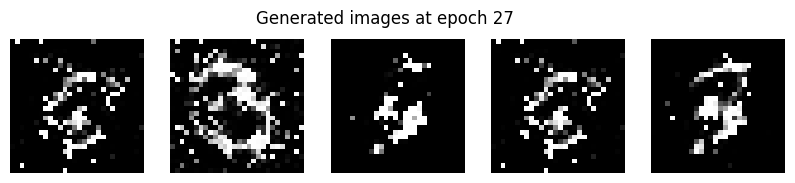

[Epoch 27/50] [Batch 0/938] [D loss: 0.168530] [G loss: 3.184073]
[Epoch 27/50] [Batch 1/938] [D loss: 0.186656] [G loss: 2.240425]
[Epoch 27/50] [Batch 2/938] [D loss: 0.156873] [G loss: 1.928243]
[Epoch 27/50] [Batch 3/938] [D loss: 0.180826] [G loss: 3.286675]
[Epoch 27/50] [Batch 4/938] [D loss: 0.249536] [G loss: 2.129288]
[Epoch 27/50] [Batch 5/938] [D loss: 0.256675] [G loss: 1.764323]
[Epoch 27/50] [Batch 6/938] [D loss: 0.103770] [G loss: 3.074596]
[Epoch 27/50] [Batch 7/938] [D loss: 0.185138] [G loss: 2.942842]
[Epoch 27/50] [Batch 8/938] [D loss: 0.216557] [G loss: 1.842080]
[Epoch 27/50] [Batch 9/938] [D loss: 0.128318] [G loss: 2.931583]
[Epoch 27/50] [Batch 10/938] [D loss: 0.216248] [G loss: 2.967980]
[Epoch 27/50] [Batch 11/938] [D loss: 0.286309] [G loss: 1.268630]
[Epoch 27/50] [Batch 12/938] [D loss: 0.252604] [G loss: 4.233562]
[Epoch 27/50] [Batch 13/938] [D loss: 0.160087] [G loss: 2.799567]
[Epoch 27/50] [Batch 14/938] [D loss: 0.280503] [G loss: 1.285594]
[Epoc

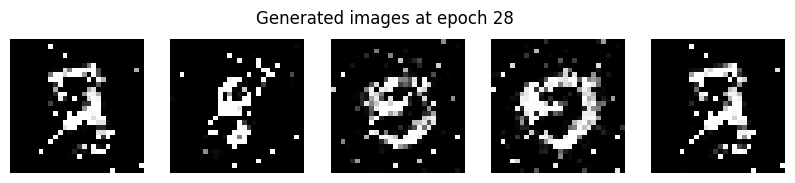

[Epoch 28/50] [Batch 0/938] [D loss: 0.081222] [G loss: 3.544712]
[Epoch 28/50] [Batch 1/938] [D loss: 0.165362] [G loss: 2.691648]
[Epoch 28/50] [Batch 2/938] [D loss: 0.236641] [G loss: 2.121996]
[Epoch 28/50] [Batch 3/938] [D loss: 0.170098] [G loss: 3.547474]
[Epoch 28/50] [Batch 4/938] [D loss: 0.204292] [G loss: 2.546459]
[Epoch 28/50] [Batch 5/938] [D loss: 0.217762] [G loss: 2.297879]
[Epoch 28/50] [Batch 6/938] [D loss: 0.278502] [G loss: 3.141360]
[Epoch 28/50] [Batch 7/938] [D loss: 0.305179] [G loss: 1.302480]
[Epoch 28/50] [Batch 8/938] [D loss: 0.543322] [G loss: 5.310450]
[Epoch 28/50] [Batch 9/938] [D loss: 0.189001] [G loss: 1.635859]
[Epoch 28/50] [Batch 10/938] [D loss: 0.107301] [G loss: 2.879470]
[Epoch 28/50] [Batch 11/938] [D loss: 0.148527] [G loss: 2.703652]
[Epoch 28/50] [Batch 12/938] [D loss: 0.212465] [G loss: 1.870767]
[Epoch 28/50] [Batch 13/938] [D loss: 0.155293] [G loss: 2.884528]
[Epoch 28/50] [Batch 14/938] [D loss: 0.379598] [G loss: 2.627510]
[Epoc

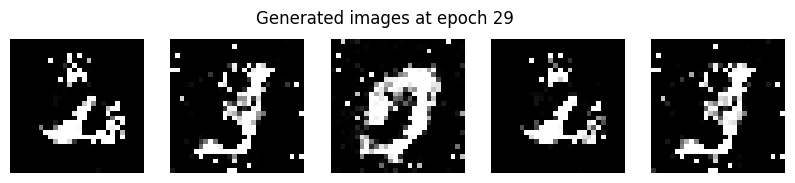

[Epoch 29/50] [Batch 0/938] [D loss: 0.153638] [G loss: 4.000201]
[Epoch 29/50] [Batch 1/938] [D loss: 0.140066] [G loss: 3.113673]
[Epoch 29/50] [Batch 2/938] [D loss: 0.128053] [G loss: 2.332495]
[Epoch 29/50] [Batch 3/938] [D loss: 0.169306] [G loss: 3.521821]
[Epoch 29/50] [Batch 4/938] [D loss: 0.172246] [G loss: 2.071007]
[Epoch 29/50] [Batch 5/938] [D loss: 0.093965] [G loss: 2.718768]
[Epoch 29/50] [Batch 6/938] [D loss: 0.096247] [G loss: 3.546275]
[Epoch 29/50] [Batch 7/938] [D loss: 0.145847] [G loss: 2.793706]
[Epoch 29/50] [Batch 8/938] [D loss: 0.132029] [G loss: 2.213555]
[Epoch 29/50] [Batch 9/938] [D loss: 0.164939] [G loss: 3.028344]
[Epoch 29/50] [Batch 10/938] [D loss: 0.154440] [G loss: 2.369546]
[Epoch 29/50] [Batch 11/938] [D loss: 0.141906] [G loss: 2.944569]
[Epoch 29/50] [Batch 12/938] [D loss: 0.170153] [G loss: 2.982541]
[Epoch 29/50] [Batch 13/938] [D loss: 0.240566] [G loss: 2.082676]
[Epoch 29/50] [Batch 14/938] [D loss: 0.209961] [G loss: 2.401863]
[Epoc

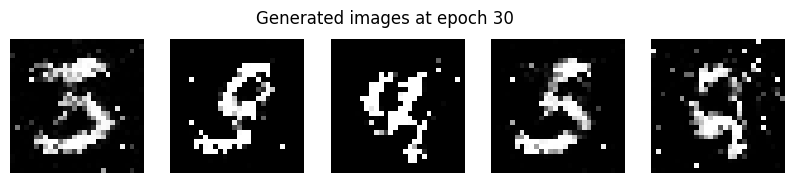

[Epoch 30/50] [Batch 0/938] [D loss: 0.089567] [G loss: 2.430857]
[Epoch 30/50] [Batch 1/938] [D loss: 0.200319] [G loss: 3.461854]
[Epoch 30/50] [Batch 2/938] [D loss: 0.210369] [G loss: 2.501909]
[Epoch 30/50] [Batch 3/938] [D loss: 0.205737] [G loss: 1.902345]
[Epoch 30/50] [Batch 4/938] [D loss: 0.193015] [G loss: 4.695844]
[Epoch 30/50] [Batch 5/938] [D loss: 0.128623] [G loss: 3.537551]
[Epoch 30/50] [Batch 6/938] [D loss: 0.189313] [G loss: 2.521275]
[Epoch 30/50] [Batch 7/938] [D loss: 0.133855] [G loss: 2.787877]
[Epoch 30/50] [Batch 8/938] [D loss: 0.143515] [G loss: 3.749028]
[Epoch 30/50] [Batch 9/938] [D loss: 0.124270] [G loss: 2.061101]
[Epoch 30/50] [Batch 10/938] [D loss: 0.080717] [G loss: 3.515591]
[Epoch 30/50] [Batch 11/938] [D loss: 0.181892] [G loss: 3.097858]
[Epoch 30/50] [Batch 12/938] [D loss: 0.183702] [G loss: 1.577349]
[Epoch 30/50] [Batch 13/938] [D loss: 0.306600] [G loss: 4.635585]
[Epoch 30/50] [Batch 14/938] [D loss: 0.244448] [G loss: 2.398712]
[Epoc

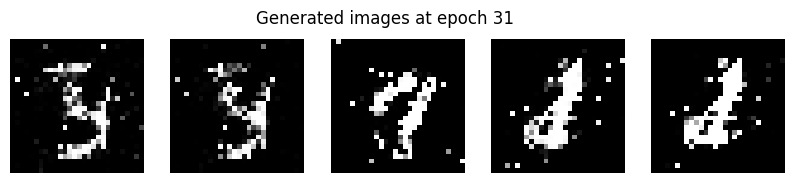

[Epoch 31/50] [Batch 0/938] [D loss: 0.209593] [G loss: 5.322350]
[Epoch 31/50] [Batch 1/938] [D loss: 0.156652] [G loss: 3.642735]
[Epoch 31/50] [Batch 2/938] [D loss: 0.325698] [G loss: 1.023694]
[Epoch 31/50] [Batch 3/938] [D loss: 0.297307] [G loss: 7.007085]
[Epoch 31/50] [Batch 4/938] [D loss: 0.270585] [G loss: 5.616784]
[Epoch 31/50] [Batch 5/938] [D loss: 0.205744] [G loss: 1.526702]
[Epoch 31/50] [Batch 6/938] [D loss: 0.058510] [G loss: 3.528015]
[Epoch 31/50] [Batch 7/938] [D loss: 0.066082] [G loss: 4.068063]
[Epoch 31/50] [Batch 8/938] [D loss: 0.098254] [G loss: 3.279585]
[Epoch 31/50] [Batch 9/938] [D loss: 0.096602] [G loss: 2.354945]
[Epoch 31/50] [Batch 10/938] [D loss: 0.109726] [G loss: 2.786212]
[Epoch 31/50] [Batch 11/938] [D loss: 0.105934] [G loss: 3.124130]
[Epoch 31/50] [Batch 12/938] [D loss: 0.098127] [G loss: 2.321032]
[Epoch 31/50] [Batch 13/938] [D loss: 0.105789] [G loss: 2.833829]
[Epoch 31/50] [Batch 14/938] [D loss: 0.147397] [G loss: 2.567791]
[Epoc

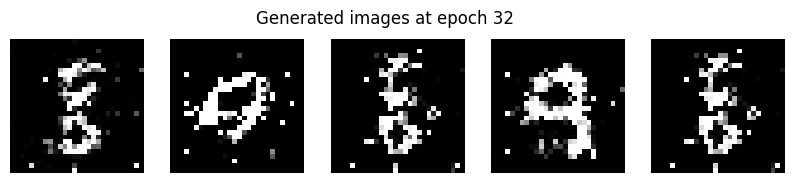

[Epoch 32/50] [Batch 0/938] [D loss: 0.099774] [G loss: 4.136070]
[Epoch 32/50] [Batch 1/938] [D loss: 0.123144] [G loss: 3.666608]
[Epoch 32/50] [Batch 2/938] [D loss: 0.129381] [G loss: 1.869788]
[Epoch 32/50] [Batch 3/938] [D loss: 0.071774] [G loss: 3.314497]
[Epoch 32/50] [Batch 4/938] [D loss: 0.152395] [G loss: 3.415045]
[Epoch 32/50] [Batch 5/938] [D loss: 0.171533] [G loss: 1.461929]
[Epoch 32/50] [Batch 6/938] [D loss: 0.192841] [G loss: 5.307614]
[Epoch 32/50] [Batch 7/938] [D loss: 0.106410] [G loss: 3.328483]
[Epoch 32/50] [Batch 8/938] [D loss: 0.180960] [G loss: 1.495632]
[Epoch 32/50] [Batch 9/938] [D loss: 0.173227] [G loss: 5.222807]
[Epoch 32/50] [Batch 10/938] [D loss: 0.153825] [G loss: 3.964759]
[Epoch 32/50] [Batch 11/938] [D loss: 0.136923] [G loss: 1.766590]
[Epoch 32/50] [Batch 12/938] [D loss: 0.075120] [G loss: 4.227212]
[Epoch 32/50] [Batch 13/938] [D loss: 0.116091] [G loss: 3.877256]
[Epoch 32/50] [Batch 14/938] [D loss: 0.162863] [G loss: 2.031261]
[Epoc

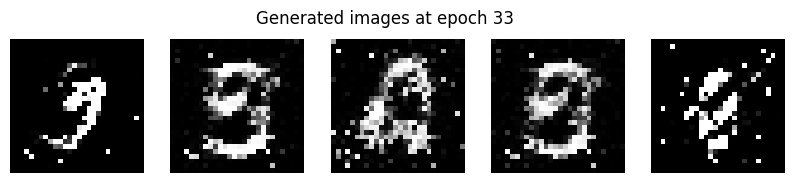

[Epoch 33/50] [Batch 0/938] [D loss: 0.185564] [G loss: 1.929498]
[Epoch 33/50] [Batch 1/938] [D loss: 0.130499] [G loss: 2.676457]
[Epoch 33/50] [Batch 2/938] [D loss: 0.112351] [G loss: 2.894292]
[Epoch 33/50] [Batch 3/938] [D loss: 0.155604] [G loss: 2.359161]
[Epoch 33/50] [Batch 4/938] [D loss: 0.169605] [G loss: 2.685247]
[Epoch 33/50] [Batch 5/938] [D loss: 0.131786] [G loss: 2.202768]
[Epoch 33/50] [Batch 6/938] [D loss: 0.206253] [G loss: 2.841532]
[Epoch 33/50] [Batch 7/938] [D loss: 0.170922] [G loss: 1.779794]
[Epoch 33/50] [Batch 8/938] [D loss: 0.108745] [G loss: 3.010376]
[Epoch 33/50] [Batch 9/938] [D loss: 0.136575] [G loss: 2.799924]
[Epoch 33/50] [Batch 10/938] [D loss: 0.149981] [G loss: 2.019229]
[Epoch 33/50] [Batch 11/938] [D loss: 0.174269] [G loss: 3.084552]
[Epoch 33/50] [Batch 12/938] [D loss: 0.199280] [G loss: 1.814653]
[Epoch 33/50] [Batch 13/938] [D loss: 0.169932] [G loss: 3.026880]
[Epoch 33/50] [Batch 14/938] [D loss: 0.128908] [G loss: 2.207061]
[Epoc

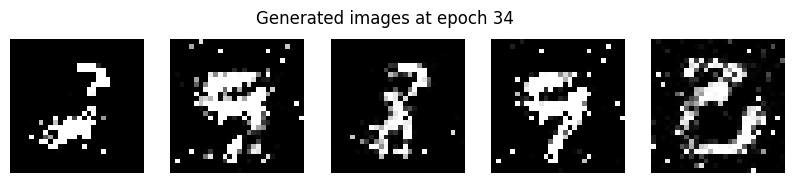

[Epoch 34/50] [Batch 0/938] [D loss: 0.233420] [G loss: 4.053838]
[Epoch 34/50] [Batch 1/938] [D loss: 0.129660] [G loss: 2.650155]
[Epoch 34/50] [Batch 2/938] [D loss: 0.200613] [G loss: 2.624039]
[Epoch 34/50] [Batch 3/938] [D loss: 0.120266] [G loss: 3.205349]
[Epoch 34/50] [Batch 4/938] [D loss: 0.156874] [G loss: 2.250357]
[Epoch 34/50] [Batch 5/938] [D loss: 0.190044] [G loss: 2.511724]
[Epoch 34/50] [Batch 6/938] [D loss: 0.151090] [G loss: 2.599517]
[Epoch 34/50] [Batch 7/938] [D loss: 0.153299] [G loss: 2.420866]
[Epoch 34/50] [Batch 8/938] [D loss: 0.164765] [G loss: 2.911630]
[Epoch 34/50] [Batch 9/938] [D loss: 0.155601] [G loss: 1.922235]
[Epoch 34/50] [Batch 10/938] [D loss: 0.185459] [G loss: 3.416702]
[Epoch 34/50] [Batch 11/938] [D loss: 0.238509] [G loss: 1.598668]
[Epoch 34/50] [Batch 12/938] [D loss: 0.336696] [G loss: 5.544512]
[Epoch 34/50] [Batch 13/938] [D loss: 0.258248] [G loss: 2.166960]
[Epoch 34/50] [Batch 14/938] [D loss: 0.261440] [G loss: 3.000031]
[Epoc

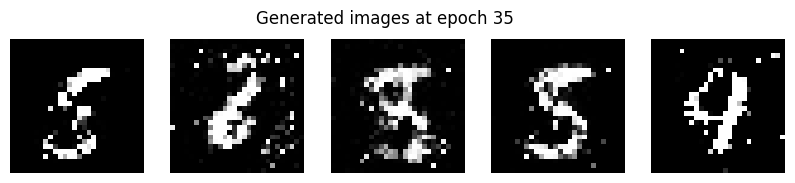

[Epoch 35/50] [Batch 0/938] [D loss: 0.163045] [G loss: 1.663184]
[Epoch 35/50] [Batch 1/938] [D loss: 0.225025] [G loss: 3.421509]
[Epoch 35/50] [Batch 2/938] [D loss: 0.134306] [G loss: 2.244789]
[Epoch 35/50] [Batch 3/938] [D loss: 0.194194] [G loss: 3.160662]
[Epoch 35/50] [Batch 4/938] [D loss: 0.107001] [G loss: 2.572208]
[Epoch 35/50] [Batch 5/938] [D loss: 0.123919] [G loss: 2.261696]
[Epoch 35/50] [Batch 6/938] [D loss: 0.124629] [G loss: 3.371668]
[Epoch 35/50] [Batch 7/938] [D loss: 0.086564] [G loss: 2.693888]
[Epoch 35/50] [Batch 8/938] [D loss: 0.229380] [G loss: 2.691269]
[Epoch 35/50] [Batch 9/938] [D loss: 0.188649] [G loss: 1.815093]
[Epoch 35/50] [Batch 10/938] [D loss: 0.072067] [G loss: 3.338553]
[Epoch 35/50] [Batch 11/938] [D loss: 0.137282] [G loss: 3.512804]
[Epoch 35/50] [Batch 12/938] [D loss: 0.153063] [G loss: 1.939371]
[Epoch 35/50] [Batch 13/938] [D loss: 0.205265] [G loss: 3.484632]
[Epoch 35/50] [Batch 14/938] [D loss: 0.135771] [G loss: 1.791351]
[Epoc

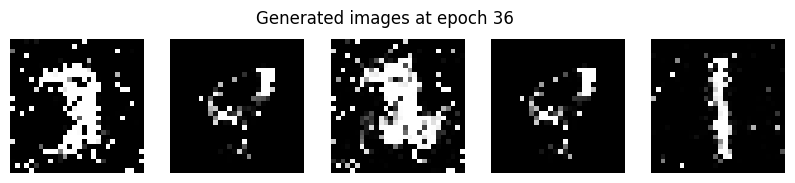

[Epoch 36/50] [Batch 0/938] [D loss: 0.127990] [G loss: 7.540791]
[Epoch 36/50] [Batch 1/938] [D loss: 0.076343] [G loss: 5.939154]
[Epoch 36/50] [Batch 2/938] [D loss: 0.171521] [G loss: 4.499461]
[Epoch 36/50] [Batch 3/938] [D loss: 0.120686] [G loss: 4.037613]
[Epoch 36/50] [Batch 4/938] [D loss: 0.063894] [G loss: 3.877752]
[Epoch 36/50] [Batch 5/938] [D loss: 0.076584] [G loss: 3.124185]
[Epoch 36/50] [Batch 6/938] [D loss: 0.054733] [G loss: 3.307579]
[Epoch 36/50] [Batch 7/938] [D loss: 0.103466] [G loss: 3.150981]
[Epoch 36/50] [Batch 8/938] [D loss: 0.140843] [G loss: 2.241478]
[Epoch 36/50] [Batch 9/938] [D loss: 0.065793] [G loss: 2.679580]
[Epoch 36/50] [Batch 10/938] [D loss: 0.124643] [G loss: 4.086199]
[Epoch 36/50] [Batch 11/938] [D loss: 0.096993] [G loss: 2.253080]
[Epoch 36/50] [Batch 12/938] [D loss: 0.149965] [G loss: 3.698250]
[Epoch 36/50] [Batch 13/938] [D loss: 0.120239] [G loss: 2.316585]
[Epoch 36/50] [Batch 14/938] [D loss: 0.104857] [G loss: 3.738416]
[Epoc

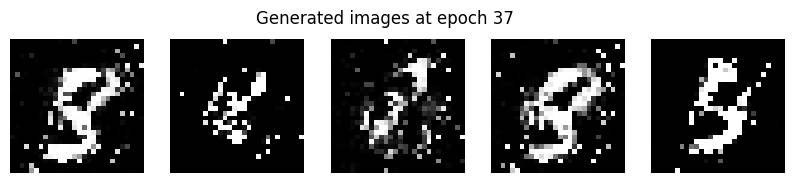

[Epoch 37/50] [Batch 0/938] [D loss: 0.075360] [G loss: 3.149222]
[Epoch 37/50] [Batch 1/938] [D loss: 0.128570] [G loss: 3.481798]
[Epoch 37/50] [Batch 2/938] [D loss: 0.180254] [G loss: 2.288825]
[Epoch 37/50] [Batch 3/938] [D loss: 0.107982] [G loss: 3.070065]
[Epoch 37/50] [Batch 4/938] [D loss: 0.139644] [G loss: 2.737710]
[Epoch 37/50] [Batch 5/938] [D loss: 0.167025] [G loss: 2.259986]
[Epoch 37/50] [Batch 6/938] [D loss: 0.142530] [G loss: 3.704547]
[Epoch 37/50] [Batch 7/938] [D loss: 0.101605] [G loss: 2.584805]
[Epoch 37/50] [Batch 8/938] [D loss: 0.082438] [G loss: 2.550407]
[Epoch 37/50] [Batch 9/938] [D loss: 0.279211] [G loss: 3.701374]
[Epoch 37/50] [Batch 10/938] [D loss: 0.213895] [G loss: 1.335818]
[Epoch 37/50] [Batch 11/938] [D loss: 0.251059] [G loss: 5.440819]
[Epoch 37/50] [Batch 12/938] [D loss: 0.200763] [G loss: 3.505064]
[Epoch 37/50] [Batch 13/938] [D loss: 0.451695] [G loss: 0.874444]
[Epoch 37/50] [Batch 14/938] [D loss: 0.350575] [G loss: 8.688214]
[Epoc

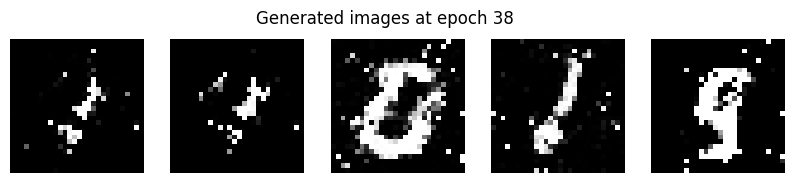

[Epoch 38/50] [Batch 0/938] [D loss: 0.130147] [G loss: 3.104323]
[Epoch 38/50] [Batch 1/938] [D loss: 0.121512] [G loss: 2.608390]
[Epoch 38/50] [Batch 2/938] [D loss: 0.144405] [G loss: 2.261421]
[Epoch 38/50] [Batch 3/938] [D loss: 0.140153] [G loss: 3.954882]
[Epoch 38/50] [Batch 4/938] [D loss: 0.111859] [G loss: 2.919976]
[Epoch 38/50] [Batch 5/938] [D loss: 0.087637] [G loss: 3.514747]
[Epoch 38/50] [Batch 6/938] [D loss: 0.078874] [G loss: 2.934179]
[Epoch 38/50] [Batch 7/938] [D loss: 0.110371] [G loss: 2.752727]
[Epoch 38/50] [Batch 8/938] [D loss: 0.100641] [G loss: 2.878084]
[Epoch 38/50] [Batch 9/938] [D loss: 0.118090] [G loss: 2.838901]
[Epoch 38/50] [Batch 10/938] [D loss: 0.055421] [G loss: 3.077095]
[Epoch 38/50] [Batch 11/938] [D loss: 0.182131] [G loss: 3.900416]
[Epoch 38/50] [Batch 12/938] [D loss: 0.128519] [G loss: 2.263216]
[Epoch 38/50] [Batch 13/938] [D loss: 0.063321] [G loss: 3.745231]
[Epoch 38/50] [Batch 14/938] [D loss: 0.141156] [G loss: 3.682345]
[Epoc

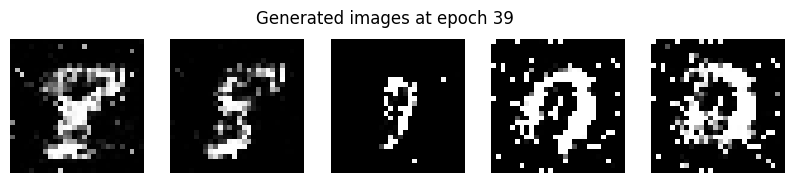

[Epoch 39/50] [Batch 0/938] [D loss: 0.240494] [G loss: 1.799396]
[Epoch 39/50] [Batch 1/938] [D loss: 0.140473] [G loss: 5.395301]
[Epoch 39/50] [Batch 2/938] [D loss: 0.200931] [G loss: 4.786412]
[Epoch 39/50] [Batch 3/938] [D loss: 0.464719] [G loss: 1.026499]
[Epoch 39/50] [Batch 4/938] [D loss: 0.648733] [G loss: 7.728770]
[Epoch 39/50] [Batch 5/938] [D loss: 0.218064] [G loss: 3.373399]
[Epoch 39/50] [Batch 6/938] [D loss: 0.120694] [G loss: 3.714998]
[Epoch 39/50] [Batch 7/938] [D loss: 0.121716] [G loss: 2.896996]
[Epoch 39/50] [Batch 8/938] [D loss: 0.085108] [G loss: 2.971009]
[Epoch 39/50] [Batch 9/938] [D loss: 0.076261] [G loss: 3.464969]
[Epoch 39/50] [Batch 10/938] [D loss: 0.083099] [G loss: 3.454515]
[Epoch 39/50] [Batch 11/938] [D loss: 0.176064] [G loss: 2.428305]
[Epoch 39/50] [Batch 12/938] [D loss: 0.224351] [G loss: 2.952455]
[Epoch 39/50] [Batch 13/938] [D loss: 0.173198] [G loss: 2.400214]
[Epoch 39/50] [Batch 14/938] [D loss: 0.227987] [G loss: 2.540909]
[Epoc

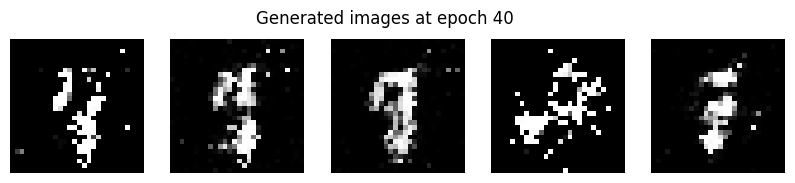

[Epoch 40/50] [Batch 0/938] [D loss: 0.082160] [G loss: 2.845393]
[Epoch 40/50] [Batch 1/938] [D loss: 0.102886] [G loss: 3.505385]
[Epoch 40/50] [Batch 2/938] [D loss: 0.171058] [G loss: 2.862609]
[Epoch 40/50] [Batch 3/938] [D loss: 0.182225] [G loss: 1.477327]
[Epoch 40/50] [Batch 4/938] [D loss: 0.308244] [G loss: 6.517417]
[Epoch 40/50] [Batch 5/938] [D loss: 0.144112] [G loss: 4.084021]
[Epoch 40/50] [Batch 6/938] [D loss: 0.205729] [G loss: 1.640065]
[Epoch 40/50] [Batch 7/938] [D loss: 0.096543] [G loss: 5.345135]
[Epoch 40/50] [Batch 8/938] [D loss: 0.057612] [G loss: 5.244224]
[Epoch 40/50] [Batch 9/938] [D loss: 0.166935] [G loss: 3.233691]
[Epoch 40/50] [Batch 10/938] [D loss: 0.278503] [G loss: 1.525174]
[Epoch 40/50] [Batch 11/938] [D loss: 0.274224] [G loss: 6.533055]
[Epoch 40/50] [Batch 12/938] [D loss: 0.152191] [G loss: 4.411801]
[Epoch 40/50] [Batch 13/938] [D loss: 0.210240] [G loss: 2.332980]
[Epoch 40/50] [Batch 14/938] [D loss: 0.174012] [G loss: 6.272587]
[Epoc

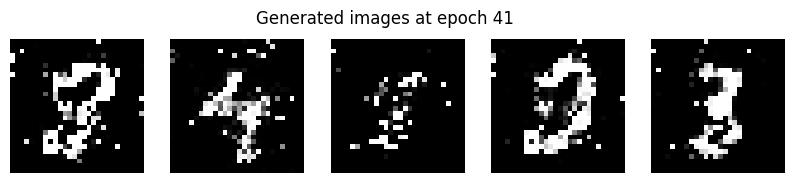

[Epoch 41/50] [Batch 0/938] [D loss: 0.378029] [G loss: 2.259115]
[Epoch 41/50] [Batch 1/938] [D loss: 0.189633] [G loss: 6.225614]
[Epoch 41/50] [Batch 2/938] [D loss: 0.154200] [G loss: 5.544363]
[Epoch 41/50] [Batch 3/938] [D loss: 0.084774] [G loss: 3.659223]
[Epoch 41/50] [Batch 4/938] [D loss: 0.101632] [G loss: 3.739823]
[Epoch 41/50] [Batch 5/938] [D loss: 0.083523] [G loss: 3.321150]
[Epoch 41/50] [Batch 6/938] [D loss: 0.103752] [G loss: 2.838136]
[Epoch 41/50] [Batch 7/938] [D loss: 0.072592] [G loss: 3.408633]
[Epoch 41/50] [Batch 8/938] [D loss: 0.125077] [G loss: 3.492355]
[Epoch 41/50] [Batch 9/938] [D loss: 0.093325] [G loss: 2.937248]
[Epoch 41/50] [Batch 10/938] [D loss: 0.162195] [G loss: 2.471329]
[Epoch 41/50] [Batch 11/938] [D loss: 0.164704] [G loss: 3.783862]
[Epoch 41/50] [Batch 12/938] [D loss: 0.138988] [G loss: 3.161926]
[Epoch 41/50] [Batch 13/938] [D loss: 0.129012] [G loss: 2.079692]
[Epoch 41/50] [Batch 14/938] [D loss: 0.100668] [G loss: 4.276349]
[Epoc

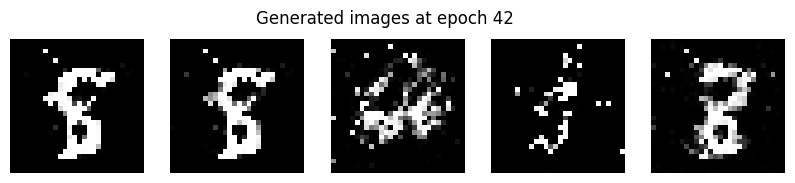

[Epoch 42/50] [Batch 0/938] [D loss: 0.240876] [G loss: 4.664591]
[Epoch 42/50] [Batch 1/938] [D loss: 0.242420] [G loss: 3.199803]
[Epoch 42/50] [Batch 2/938] [D loss: 0.222802] [G loss: 2.902156]
[Epoch 42/50] [Batch 3/938] [D loss: 0.069147] [G loss: 3.103849]
[Epoch 42/50] [Batch 4/938] [D loss: 0.059598] [G loss: 3.731428]
[Epoch 42/50] [Batch 5/938] [D loss: 0.089489] [G loss: 3.459275]
[Epoch 42/50] [Batch 6/938] [D loss: 0.236689] [G loss: 3.495665]
[Epoch 42/50] [Batch 7/938] [D loss: 0.127529] [G loss: 2.334028]
[Epoch 42/50] [Batch 8/938] [D loss: 0.241708] [G loss: 4.914452]
[Epoch 42/50] [Batch 9/938] [D loss: 0.155991] [G loss: 2.432329]
[Epoch 42/50] [Batch 10/938] [D loss: 0.175873] [G loss: 2.598225]
[Epoch 42/50] [Batch 11/938] [D loss: 0.091177] [G loss: 2.808983]
[Epoch 42/50] [Batch 12/938] [D loss: 0.192982] [G loss: 3.403638]
[Epoch 42/50] [Batch 13/938] [D loss: 0.165352] [G loss: 1.716390]
[Epoch 42/50] [Batch 14/938] [D loss: 0.089690] [G loss: 4.713968]
[Epoc

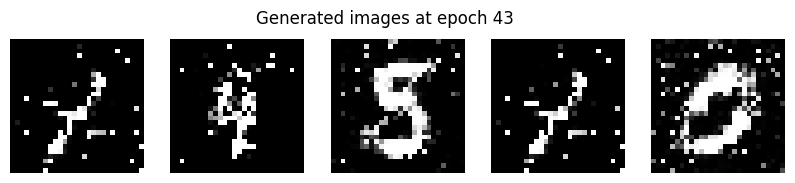

[Epoch 43/50] [Batch 0/938] [D loss: 0.070038] [G loss: 3.779625]
[Epoch 43/50] [Batch 1/938] [D loss: 0.157830] [G loss: 3.726036]
[Epoch 43/50] [Batch 2/938] [D loss: 0.095452] [G loss: 2.783530]
[Epoch 43/50] [Batch 3/938] [D loss: 0.081486] [G loss: 4.377794]
[Epoch 43/50] [Batch 4/938] [D loss: 0.136096] [G loss: 3.933945]
[Epoch 43/50] [Batch 5/938] [D loss: 0.150871] [G loss: 1.977050]
[Epoch 43/50] [Batch 6/938] [D loss: 0.154307] [G loss: 4.821112]
[Epoch 43/50] [Batch 7/938] [D loss: 0.159162] [G loss: 4.649022]
[Epoch 43/50] [Batch 8/938] [D loss: 0.190855] [G loss: 2.165660]
[Epoch 43/50] [Batch 9/938] [D loss: 0.066023] [G loss: 3.868793]
[Epoch 43/50] [Batch 10/938] [D loss: 0.181646] [G loss: 3.689672]
[Epoch 43/50] [Batch 11/938] [D loss: 0.119344] [G loss: 2.563231]
[Epoch 43/50] [Batch 12/938] [D loss: 0.098746] [G loss: 2.986865]
[Epoch 43/50] [Batch 13/938] [D loss: 0.097992] [G loss: 2.934262]
[Epoch 43/50] [Batch 14/938] [D loss: 0.163060] [G loss: 3.131058]
[Epoc

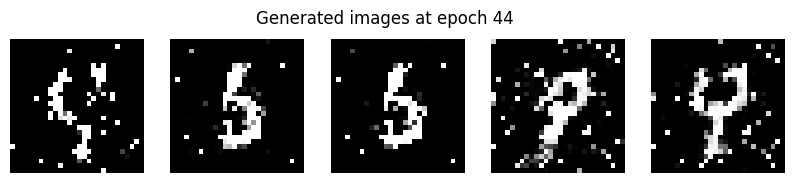

[Epoch 44/50] [Batch 0/938] [D loss: 0.133042] [G loss: 3.600744]
[Epoch 44/50] [Batch 1/938] [D loss: 0.109970] [G loss: 2.461755]
[Epoch 44/50] [Batch 2/938] [D loss: 0.054465] [G loss: 3.078636]
[Epoch 44/50] [Batch 3/938] [D loss: 0.092172] [G loss: 3.926082]
[Epoch 44/50] [Batch 4/938] [D loss: 0.041259] [G loss: 3.615548]
[Epoch 44/50] [Batch 5/938] [D loss: 0.144993] [G loss: 3.421807]
[Epoch 44/50] [Batch 6/938] [D loss: 0.063720] [G loss: 3.146640]
[Epoch 44/50] [Batch 7/938] [D loss: 0.063663] [G loss: 2.989218]
[Epoch 44/50] [Batch 8/938] [D loss: 0.115950] [G loss: 4.099086]
[Epoch 44/50] [Batch 9/938] [D loss: 0.069370] [G loss: 3.149104]
[Epoch 44/50] [Batch 10/938] [D loss: 0.096162] [G loss: 2.780772]
[Epoch 44/50] [Batch 11/938] [D loss: 0.082498] [G loss: 3.202579]
[Epoch 44/50] [Batch 12/938] [D loss: 0.067271] [G loss: 3.462111]
[Epoch 44/50] [Batch 13/938] [D loss: 0.103708] [G loss: 3.443876]
[Epoch 44/50] [Batch 14/938] [D loss: 0.070912] [G loss: 2.669434]
[Epoc

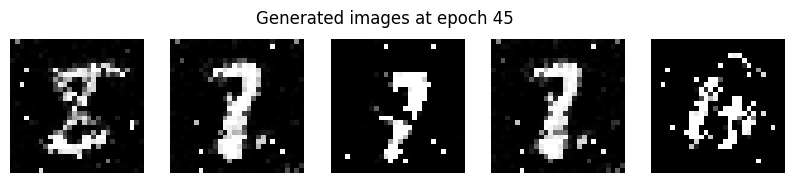

[Epoch 45/50] [Batch 0/938] [D loss: 0.109254] [G loss: 2.909569]
[Epoch 45/50] [Batch 1/938] [D loss: 0.122613] [G loss: 2.716298]
[Epoch 45/50] [Batch 2/938] [D loss: 0.115977] [G loss: 2.338943]
[Epoch 45/50] [Batch 3/938] [D loss: 0.076112] [G loss: 3.203491]
[Epoch 45/50] [Batch 4/938] [D loss: 0.115693] [G loss: 3.209753]
[Epoch 45/50] [Batch 5/938] [D loss: 0.138095] [G loss: 2.068287]
[Epoch 45/50] [Batch 6/938] [D loss: 0.205342] [G loss: 3.129505]
[Epoch 45/50] [Batch 7/938] [D loss: 0.191304] [G loss: 2.032014]
[Epoch 45/50] [Batch 8/938] [D loss: 0.068321] [G loss: 3.139896]
[Epoch 45/50] [Batch 9/938] [D loss: 0.119869] [G loss: 3.222001]
[Epoch 45/50] [Batch 10/938] [D loss: 0.144660] [G loss: 2.182336]
[Epoch 45/50] [Batch 11/938] [D loss: 0.108347] [G loss: 3.244058]
[Epoch 45/50] [Batch 12/938] [D loss: 0.067946] [G loss: 2.966830]
[Epoch 45/50] [Batch 13/938] [D loss: 0.113946] [G loss: 2.943303]
[Epoch 45/50] [Batch 14/938] [D loss: 0.160433] [G loss: 1.902835]
[Epoc

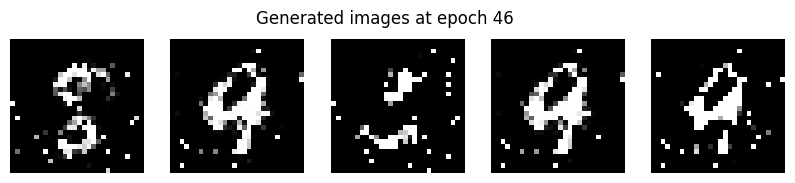

[Epoch 46/50] [Batch 0/938] [D loss: 0.093101] [G loss: 3.853846]
[Epoch 46/50] [Batch 1/938] [D loss: 0.063405] [G loss: 3.247386]
[Epoch 46/50] [Batch 2/938] [D loss: 0.070635] [G loss: 3.583169]
[Epoch 46/50] [Batch 3/938] [D loss: 0.090774] [G loss: 3.756148]
[Epoch 46/50] [Batch 4/938] [D loss: 0.126241] [G loss: 2.933379]
[Epoch 46/50] [Batch 5/938] [D loss: 0.110241] [G loss: 2.977710]
[Epoch 46/50] [Batch 6/938] [D loss: 0.024803] [G loss: 4.453254]
[Epoch 46/50] [Batch 7/938] [D loss: 0.052034] [G loss: 4.491051]
[Epoch 46/50] [Batch 8/938] [D loss: 0.067168] [G loss: 3.857330]
[Epoch 46/50] [Batch 9/938] [D loss: 0.118605] [G loss: 2.734695]
[Epoch 46/50] [Batch 10/938] [D loss: 0.076386] [G loss: 3.968266]
[Epoch 46/50] [Batch 11/938] [D loss: 0.113955] [G loss: 3.077965]
[Epoch 46/50] [Batch 12/938] [D loss: 0.139352] [G loss: 2.793864]
[Epoch 46/50] [Batch 13/938] [D loss: 0.109096] [G loss: 3.254886]
[Epoch 46/50] [Batch 14/938] [D loss: 0.101666] [G loss: 2.710881]
[Epoc

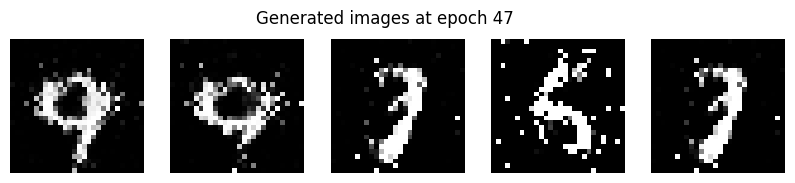

[Epoch 47/50] [Batch 0/938] [D loss: 0.101103] [G loss: 3.020765]
[Epoch 47/50] [Batch 1/938] [D loss: 0.106527] [G loss: 3.725439]
[Epoch 47/50] [Batch 2/938] [D loss: 0.175959] [G loss: 2.313410]
[Epoch 47/50] [Batch 3/938] [D loss: 0.168796] [G loss: 3.326898]
[Epoch 47/50] [Batch 4/938] [D loss: 0.180385] [G loss: 2.092656]
[Epoch 47/50] [Batch 5/938] [D loss: 0.209355] [G loss: 4.226919]
[Epoch 47/50] [Batch 6/938] [D loss: 0.082851] [G loss: 2.582973]
[Epoch 47/50] [Batch 7/938] [D loss: 0.172404] [G loss: 2.415936]
[Epoch 47/50] [Batch 8/938] [D loss: 0.107667] [G loss: 3.802878]
[Epoch 47/50] [Batch 9/938] [D loss: 0.161306] [G loss: 3.283747]
[Epoch 47/50] [Batch 10/938] [D loss: 0.192333] [G loss: 1.840227]
[Epoch 47/50] [Batch 11/938] [D loss: 0.195788] [G loss: 4.328324]
[Epoch 47/50] [Batch 12/938] [D loss: 0.094725] [G loss: 2.763772]
[Epoch 47/50] [Batch 13/938] [D loss: 0.083633] [G loss: 3.214118]
[Epoch 47/50] [Batch 14/938] [D loss: 0.212553] [G loss: 3.458670]
[Epoc

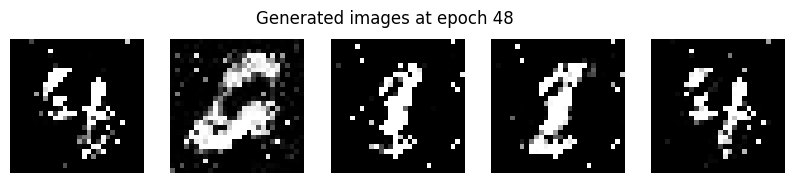

[Epoch 48/50] [Batch 0/938] [D loss: 0.142497] [G loss: 3.523053]
[Epoch 48/50] [Batch 1/938] [D loss: 0.090645] [G loss: 2.967786]
[Epoch 48/50] [Batch 2/938] [D loss: 0.124283] [G loss: 2.976810]
[Epoch 48/50] [Batch 3/938] [D loss: 0.097782] [G loss: 3.381544]
[Epoch 48/50] [Batch 4/938] [D loss: 0.187666] [G loss: 2.607774]
[Epoch 48/50] [Batch 5/938] [D loss: 0.243425] [G loss: 4.295233]
[Epoch 48/50] [Batch 6/938] [D loss: 0.167678] [G loss: 2.750664]
[Epoch 48/50] [Batch 7/938] [D loss: 0.125113] [G loss: 3.374408]
[Epoch 48/50] [Batch 8/938] [D loss: 0.074160] [G loss: 3.520774]
[Epoch 48/50] [Batch 9/938] [D loss: 0.122363] [G loss: 2.702145]
[Epoch 48/50] [Batch 10/938] [D loss: 0.090364] [G loss: 3.755894]
[Epoch 48/50] [Batch 11/938] [D loss: 0.075091] [G loss: 3.101923]
[Epoch 48/50] [Batch 12/938] [D loss: 0.058584] [G loss: 3.334034]
[Epoch 48/50] [Batch 13/938] [D loss: 0.178669] [G loss: 4.396759]
[Epoch 48/50] [Batch 14/938] [D loss: 0.142404] [G loss: 2.638071]
[Epoc

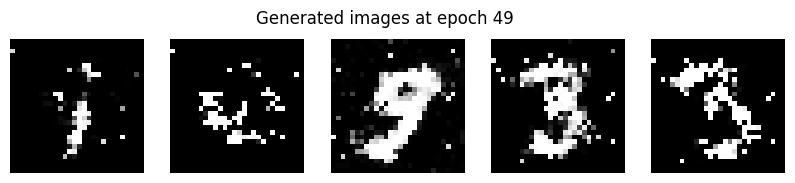

[Epoch 49/50] [Batch 0/938] [D loss: 0.222317] [G loss: 4.994189]
[Epoch 49/50] [Batch 1/938] [D loss: 0.264326] [G loss: 3.202967]
[Epoch 49/50] [Batch 2/938] [D loss: 0.204831] [G loss: 3.275273]
[Epoch 49/50] [Batch 3/938] [D loss: 0.132935] [G loss: 3.610569]
[Epoch 49/50] [Batch 4/938] [D loss: 0.149572] [G loss: 2.311371]
[Epoch 49/50] [Batch 5/938] [D loss: 0.139826] [G loss: 4.866948]
[Epoch 49/50] [Batch 6/938] [D loss: 0.092311] [G loss: 3.794557]
[Epoch 49/50] [Batch 7/938] [D loss: 0.132782] [G loss: 2.865220]
[Epoch 49/50] [Batch 8/938] [D loss: 0.188536] [G loss: 3.864865]
[Epoch 49/50] [Batch 9/938] [D loss: 0.139680] [G loss: 1.876891]
[Epoch 49/50] [Batch 10/938] [D loss: 0.144454] [G loss: 4.204666]
[Epoch 49/50] [Batch 11/938] [D loss: 0.077135] [G loss: 3.110468]
[Epoch 49/50] [Batch 12/938] [D loss: 0.121375] [G loss: 2.395092]
[Epoch 49/50] [Batch 13/938] [D loss: 0.177508] [G loss: 4.153778]
[Epoch 49/50] [Batch 14/938] [D loss: 0.182606] [G loss: 2.020559]
[Epoc

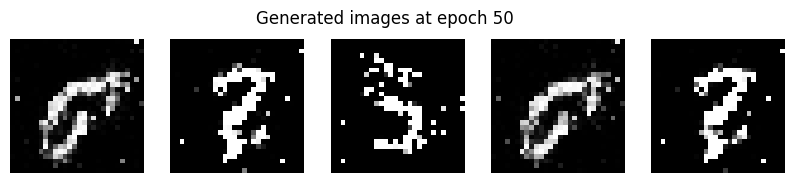

In [16]:
for epoch in range(n_epochs):
    for i, (imgs, _) in enumerate(dataloader):

        # Adversarial ground truths
        valid = Variable(Tensor(imgs.size(0), 1).fill_(1.0), requires_grad=False)
        fake = Variable(Tensor(imgs.size(0), 1).fill_(0.0), requires_grad=False)

        # Configure input
        real_imgs = Variable(imgs.type(Tensor))

        # -----------------
        #  Train Generator
        # -----------------

        optimizer_G.zero_grad()

        # Sample noise as generator input
        z = Variable(Tensor(np.random.normal(0, 1, (imgs.shape[0], latent_dim))))

        # Generate a batch of images
        gen_imgs = generator(z)

        # Loss measures generator's ability to fool the discriminator
        g_loss = adversarial_loss(discriminator(gen_imgs), valid)

        g_loss.backward()
        optimizer_G.step()

        # ---------------------
        #  Train Discriminator
        # ---------------------

        optimizer_D.zero_grad()

        # Measure discriminator's ability to classify real from generated samples
        real_loss = adversarial_loss(discriminator(real_imgs), valid)
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()
        optimizer_D.step()

        print(
            "[Epoch %d/%d] [Batch %d/%d] [D loss: %f] [G loss: %f]"
            % (epoch, n_epochs, i, len(dataloader), d_loss.item(), g_loss.item())
        )

        batches_done = epoch * len(dataloader) + i
        if batches_done % sample_interval == 0:
            save_image(gen_imgs.data[:25], "images/%d.png" % batches_done, nrow=5, normalize=True)

    with torch.no_grad():
      z = torch.randn(5, latent_dim).type(Tensor)
      gen_imgs = generator(z)
      imgs_to_show = gen_imgs.detach().cpu().numpy()

      plt.figure(figsize=(10, 2))
      for j in range(imgs_to_show.shape[0]):
          plt.subplot(1, 5, j + 1)
          plt.imshow(imgs_to_show[j][0], cmap="gray")  # for 1 channel images
          plt.axis("off")
      plt.suptitle(f"Generated images at epoch {epoch+1}")
      plt.show()